# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import comet_ml
import json

from sklearn.feature_selection import chi2, f_classif, r_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.draw_scripts import draw_feature_distribution
from analysis_scripts.feature import feature_stat_importance, features_correlation
from analysis_scripts.estimate_scripts import signal_estimates

CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Import Data

* Perform selection in the mass range of 8.7 $\sigma$.
* Convert cosAngle to actual cos.
* Add left and right components to some variables to treat them separately at preselection part.
* Add some new features.

In [2]:
# data_oc_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
# data_mb_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_2_new.csv')
data_mb_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_2_new.csv')

In [3]:
raw_df_list = []

# for data_oc_df, data_mb_df in zip([data_oc_df_2, data_oc_df_1], [data_mb_df_2, data_mb_df_1]):
for data_oc_df, data_mb_df in zip([data_oc_df_2], [data_mb_df_2]):
    
    data_oc_df = data_oc_df.drop(['n_event'], axis=1)

    mass_mask = (data_oc_df['mass_Lc'] > CFG.mass_interval[0]) \
                & ( data_oc_df['mass_Lc'] < CFG.mass_interval[1]) \
                & (data_oc_df['true_decay'] == 1)
    
    data_oc_df = data_oc_df[mass_mask]
    data_oc_df['tag'] = 'Sig'

    data_mb_df = data_mb_df.drop(['n_event'], axis=1)

    mass_mask = (data_mb_df['mass_Lc'] > CFG.mass_interval[0]) & ( data_mb_df['mass_Lc'] < CFG.mass_interval[1])

    data_mb_df = data_mb_df[mass_mask]
    data_mb_df['tag'] = 'Bg'

    raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)

    # Fix cosine
    raw_df['cosAngle_r_Lc_momentum_Lc_xy'] = raw_df['cosAngle_r_Lc_momentum_Lc_xy'].apply(np.cos)
    raw_df['cosAngle_r_Lc_sum_momentum_xy'] = raw_df['cosAngle_r_Lc_sum_momentum_xy'].apply(np.cos)
    raw_df['cosAngle_momentum_Lc_sum_momentum_xy'] = raw_df['cosAngle_momentum_Lc_sum_momentum_xy'].apply(np.cos)

    # For preselection only
    # raw_df['cosAngle_r_Lc_momentum_Lc_xy_left'] = raw_df.loc[raw_df['cosAngle_r_Lc_momentum_Lc_xy'] < 0, 'cosAngle_r_Lc_momentum_Lc_xy']
    # raw_df['cosAngle_r_Lc_momentum_Lc_xy_right'] = raw_df.loc[raw_df['cosAngle_r_Lc_momentum_Lc_xy'] > 0, 'cosAngle_r_Lc_momentum_Lc_xy']
    # raw_df['cosAngle_r_Lc_sum_momentum_xy_left'] = raw_df.loc[raw_df['cosAngle_r_Lc_sum_momentum_xy'] < 0, 'cosAngle_r_Lc_sum_momentum_xy']
    # raw_df['cosAngle_r_Lc_sum_momentum_xy_right'] = raw_df.loc[raw_df['cosAngle_r_Lc_sum_momentum_xy'] > 0, 'cosAngle_r_Lc_sum_momentum_xy']

    # Mass Lc
    raw_df['mass_significance'] = np.abs(raw_df['mass_Lc'] - 2.28646) / 0.001
    raw_df['mass_pt_correlation'] = raw_df['mass_Lc'] * raw_df['Pt_Lc'] / raw_df['P_Lc']
    
    # Transverse mass of the Lc
    raw_df['Mt_Lc'] = np.sqrt(raw_df['Pt_Lc']**2 + 2.28646**2)
    
    #----------------------------------------------------------------------------------------------
    # kinematic
    raw_df['p_pv_significance'] = raw_df['dist_p_PV_xy'] / (raw_df['chi2_p_PV_xy'] + 1e-6)
    raw_df['K_pv_significance'] = raw_df['dist_K_PV_xy'] / (raw_df['chi2_K_PV_xy'] + 1e-6)
    raw_df['pip_pv_significance'] = raw_df['dist_pip_PV_xy'] / (raw_df['chi2_pip_PV_xy'] + 1e-6)
    
    raw_df['p_momentum_ratio'] = raw_df['P_p'] / raw_df['P_Lc']
    raw_df['pip_momentum_ratio'] = raw_df['P_pip'] / raw_df['P_Lc']
    raw_df['K_momentum_ratio'] = raw_df['P_K'] / raw_df['P_Lc']
    
    raw_df['p_Pt_fraction'] = raw_df['Pt_p'] / raw_df['Pt_Lc']
    raw_df['pip_Pt_fraction'] = raw_df['Pt_pip'] / raw_df['Pt_Lc']
    raw_df['K_Pt_fraction'] = raw_df['Pt_K'] / raw_df['Pt_Lc']
    
    raw_df['delta_eta_p'] = np.abs(raw_df['eta_Lc'] - raw_df['eta_p'])
    raw_df['delta_eta_pip'] = np.abs(raw_df['eta_Lc'] - raw_df['eta_pip'])
    raw_df['delta_eta_K'] = np.abs(raw_df['eta_Lc'] - raw_df['eta_K'])
    
    # Min/max, range features
    raw_df['min_pt_daughter'] = raw_df[['Pt_p', 'Pt_K', 'Pt_pip']].min(axis=1)
    raw_df['max_pt_daughter'] = raw_df[['Pt_p', 'Pt_K', 'Pt_pip']].max(axis=1)
    raw_df['pt_range'] = raw_df['max_pt_daughter'] - raw_df['min_pt_daughter']
    
    raw_df['min_OA_daughter'] = raw_df[['OA_p', 'OA_K', 'OA_pip']].min(axis=1)
    raw_df['max_OA_daughter'] = raw_df[['OA_p', 'OA_K', 'OA_pip']].max(axis=1)
    raw_df['OA_range'] = raw_df['max_OA_daughter'] - raw_df['min_OA_daughter']
    
    # Energy
    raw_df['E_p'] = np.sqrt(raw_df['P_p']**2 + 0.938**2)
    raw_df['E_pip'] = np.sqrt(raw_df['P_pip']**2 + 0.140**2)
    raw_df['E_K'] = np.sqrt(raw_df['P_K']**2 + 0.494**2)
    raw_df['E_total'] = raw_df['E_p'] + raw_df['E_pip'] + raw_df['E_K']
    raw_df['pt_over_E'] = raw_df['Pt_Lc'] / np.sqrt(raw_df['P_Lc']**2 + 2.28646**2)
    
    # Transverse mass variables
    raw_df['Mt_p'] = np.sqrt(raw_df['Pt_p']**2 + 0.938**2)
    raw_df['Mt_K'] = np.sqrt(raw_df['Pt_K']**2 + 0.494**2)
    raw_df['Mt_pip'] = np.sqrt(raw_df['Pt_pip']**2 + 0.140**2)
    
    raw_df['opening_angle_sum'] = raw_df['OA_p'] + raw_df['OA_pip'] + raw_df['OA_K']
    raw_df['opening_angle_product'] = raw_df['OA_p'] * raw_df['OA_pip'] * raw_df['OA_K']
    raw_df['lifetime_opening_interaction'] = raw_df['ctau_Lc'] * (1 - raw_df['OA_p']/np.pi)
    
    raw_df['rapidity_p'] = 0.5 * np.log((raw_df['E_p'] + np.sqrt(raw_df['P_p']**2 - raw_df['Pt_p']**2)) / (raw_df['E_p'] - np.sqrt(raw_df['P_p']**2 - raw_df['Pt_p']**2) + 1e-6))
    raw_df['rapidity_K'] = 0.5 * np.log((raw_df['E_K'] + np.sqrt(raw_df['P_K']**2 - raw_df['Pt_K']**2)) / (raw_df['E_K'] - np.sqrt(raw_df['P_K']**2 - raw_df['Pt_K']**2) + 1e-6))
    raw_df['rapidity_pip'] = 0.5 * np.log((raw_df['E_pip'] + np.sqrt(raw_df['P_pip']**2 - raw_df['Pt_pip']**2)) / (raw_df['E_pip'] - np.sqrt(raw_df['P_pip']**2 - raw_df['Pt_pip']**2) + 1e-6))
    
    raw_df['Pt_p_over_Pt_K'] = raw_df['Pt_p'] / (raw_df['Pt_K'] + 1e-6)
    raw_df['Pt_p_over_Pt_pip'] = raw_df['Pt_p'] / (raw_df['Pt_pip'] + 1e-6)
    raw_df['Pt_K_over_Pt_pip'] = raw_df['Pt_K'] / (raw_df['Pt_pip'] + 1e-6)

    raw_df['P_p_over_P_K'] = raw_df['P_p'] / (raw_df['P_K'] + 1e-6)
    raw_df['P_p_over_P_pip'] = raw_df['P_p'] / (raw_df['P_pip'] + 1e-6)
    raw_df['P_K_over_P_pip'] = raw_df['P_K'] / (raw_df['P_pip'] + 1e-6)
    
    # Sum of squares
    raw_df['sum_squares_pt'] = raw_df['Pt_p']**2 + raw_df['Pt_K']**2 + raw_df['Pt_pip']**2
    raw_df['sum_squares_p'] = raw_df['P_p']**2 + raw_df['P_K']**2 + raw_df['P_pip']**2
    raw_df['sum_squares_OA'] = raw_df['OA_p']**2 + raw_df['OA_K']**2 + raw_df['OA_pip']**2
    
    raw_df['sum_abs_pt'] = abs(raw_df['Pt_p']) + abs(raw_df['Pt_K']) + abs(raw_df['Pt_pip'])
    raw_df['sum_abs_p'] = abs(raw_df['P_p']) + abs(raw_df['P_K']) + abs(raw_df['P_pip'])
    raw_df['sum_abs_OA'] = abs(raw_df['OA_p']) + abs(raw_df['OA_K']) + abs(raw_df['OA_pip'])
    
    # Ratios of norms
    raw_df['pt_norm_ratio'] = raw_df['Pt_Lc'] / (raw_df['sum_squares_pt'] + 1e-6)
    raw_df['p_norm_ratio'] = raw_df['P_Lc'] / (raw_df['sum_squares_p'] + 1e-6)
    
    # Momentum balance
    raw_df['momentum_balance'] = np.abs(raw_df['P_Lc'] - (raw_df['P_p'] + raw_df['P_K'] + raw_df['P_pip'])) / (raw_df['P_Lc'] + 1e-6)
    
    # Opening angle ratios
    raw_df['OA_p_ratio'] = raw_df['OA_p'] / (raw_df['OA_K'] + raw_df['OA_pip'] + 1e-6)
    raw_df['OA_K_ratio'] = raw_df['OA_K'] / (raw_df['OA_p'] + raw_df['OA_pip'] + 1e-6)
    raw_df['OA_pip_ratio'] = raw_df['OA_pip'] / (raw_df['OA_p'] + raw_df['OA_K'] + 1e-6)
    
    raw_df['pt_over_ctau'] = raw_df['Pt_Lc'] / (raw_df['ctau_Lc'] + 1e-6)
    raw_df['pt_over_length'] = raw_df['Pt_Lc'] / (raw_df['lengthXY_Lc'] + 1e-6)
    
    raw_df['triple_product'] = raw_df['Pt_p'] * raw_df['Pt_K'] * raw_df['Pt_pip'] * np.sin(raw_df['OA_p']) * np.sin(raw_df['OA_K']) * np.sin(raw_df['OA_pip'])
          
    # Energy asymmetry
    raw_df['energy_asymmetry_pK'] = (raw_df['E_p'] - raw_df['E_K']) / (raw_df['E_p'] + raw_df['E_K'] + 1e-6)
    raw_df['energy_asymmetry_ppip'] = (raw_df['E_p'] - raw_df['E_pip']) / (raw_df['E_p'] + raw_df['E_pip'] + 1e-6)
    raw_df['energy_asymmetry_Kpip'] = (raw_df['E_K'] - raw_df['E_pip']) / (raw_df['E_K'] + raw_df['E_pip'] + 1e-6)
    raw_df['energy_asymmetry_p_total'] = (raw_df['E_p'] - raw_df['E_total']/3) / (raw_df['E_total'] + 1e-6)
    
    # pT asymmetries
    raw_df['pt_asymmetry_p_K'] = (raw_df['Pt_p'] - raw_df['Pt_K']) / (raw_df['Pt_p'] + raw_df['Pt_K'] + 1e-6)
    raw_df['pt_asymmetry_p_pip'] = (raw_df['Pt_p'] - raw_df['Pt_pip']) / (raw_df['Pt_p'] + raw_df['Pt_pip'] + 1e-6)
    raw_df['pt_asymmetry_K_pip'] = (raw_df['Pt_K'] - raw_df['Pt_pip']) / (raw_df['Pt_K'] + raw_df['Pt_pip'] + 1e-6)  
    
    # Momentum asymmetries
    raw_df['asymmetry_p_K'] = (raw_df['P_p'] - raw_df['P_K']) / (raw_df['P_p'] + raw_df['P_K'] + 1e-6)
    raw_df['asymmetry_p_pip'] = (raw_df['P_p'] - raw_df['P_pip']) / (raw_df['P_p'] + raw_df['P_pip'] + 1e-6)
    raw_df['asymmetry_K_pip'] = (raw_df['P_K'] - raw_df['P_pip']) / (raw_df['P_K'] + raw_df['P_pip'] + 1e-6)
    
    # Opening angle asymmetries
    raw_df['OA_asymmetry_p_K'] = (raw_df['OA_p'] - raw_df['OA_K']) / (raw_df['OA_p'] + raw_df['OA_K'] + 1e-6)
    raw_df['OA_asymmetry_p_pip'] = (raw_df['OA_p'] - raw_df['OA_pip']) / (raw_df['OA_p'] + raw_df['OA_pip'] + 1e-6)
    raw_df['OA_asymmetry_K_pip'] = (raw_df['OA_K'] - raw_df['OA_pip']) / (raw_df['OA_K'] + raw_df['OA_pip'] + 1e-6)  
                  
    # Coefficient of variation (std/mean)
    raw_df['pt_cv'] = raw_df[['Pt_p', 'Pt_K', 'Pt_pip']].std(axis=1) / (raw_df[['Pt_p', 'Pt_K', 'Pt_pip']].mean(axis=1) + 1e-6)
    raw_df['OA_cv'] = raw_df[['OA_p', 'OA_K', 'OA_pip']].std(axis=1) / (raw_df[['OA_p', 'OA_K', 'OA_pip']].mean(axis=1) + 1e-6)
    
    # Correlation features
    raw_df['pt_eta_correlation_p'] = raw_df['Pt_p'] * raw_df['eta_p']
    raw_df['pt_eta_correlation_K'] = raw_df['Pt_K'] * raw_df['eta_K']
    raw_df['pt_eta_correlation_pip'] = raw_df['Pt_pip'] * raw_df['eta_pip']
    
    raw_df['pt_p_times_OA_p'] = raw_df['Pt_p'] * raw_df['OA_p']
    raw_df['pt_K_times_OA_K'] = raw_df['Pt_K'] * raw_df['OA_K']
    raw_df['pt_pip_times_OA_pip'] = raw_df['Pt_pip'] * raw_df['OA_pip']
    
    raw_df['ctau_pt_product'] = raw_df['ctau_Lc'] * raw_df['Pt_Lc']
    raw_df['mass_pt_product'] = raw_df['mass_Lc'] * raw_df['Pt_Lc']
    raw_df['xF_pt_product'] = raw_df['xF'] * raw_df['Pt_Lc']
    
    #----------------------------------------------------------------------------------------------
    # Topology
    
    # Length & ctau
    raw_df['l_over_dl_XY'] = raw_df['lengthXY_Lc'] / raw_df['dlengthXY_Lc']
    # raw_df['ctau_over_dctau'] = raw_df['ctau_Lc'] / raw_df['dctau_Lc']
    raw_df['l_over_dl_pt_product'] = raw_df['l_over_dl_XY'] * raw_df['Pt_Lc']
    
    raw_df['p_displacement_ratio'] =  raw_df['dist_p_Lc_xy'] / (raw_df['dist_p_PV_xy'] + 1e-6)
    raw_df['K_displacement_ratio'] = raw_df['dist_K_Lc_xy'] / (raw_df['dist_K_PV_xy'] + 1e-6)
    raw_df['pip_displacement_ratio'] = raw_df['dist_pip_Lc_xy'] / (raw_df['dist_pip_PV_xy'] + 1e-6)
    
    raw_df['mean_chi2_to_PV'] = (raw_df['chi2_p_PV_xy'] + raw_df['chi2_K_PV_xy'] + raw_df['chi2_pip_PV_xy']) / 3
    raw_df['mean_chi2_to_Lc'] = (raw_df['chi2_p_Lc_xy'] + raw_df['chi2_K_Lc_xy'] + raw_df['chi2_pip_Lc_xy']) / 3
    raw_df['topology_score'] = raw_df['mean_chi2_to_Lc'] / (raw_df['mean_chi2_to_PV'] + 1e-6)
    
    # DCA significance
    raw_df['Lc_dca_significance'] = raw_df['dist_Lc_PV_xy'] / (raw_df['chi2_Lc_PV_xy'] + 1e-6)
    raw_df['p_PV_dca_significance'] = raw_df['dist_p_PV_xy'] / (raw_df['chi2_p_PV_xy'] + 1e-6)
    raw_df['K_PV_dca_significance'] = raw_df['dist_K_PV_xy'] / (raw_df['chi2_K_PV_xy'] + 1e-6)
    raw_df['pip_PV_dca_significance'] = raw_df['dist_pip_PV_xy'] / (raw_df['chi2_pip_PV_xy'] + 1e-6)
    raw_df['p_Lc_dca_significance'] = raw_df['dist_p_Lc_xy'] / (raw_df['chi2_p_Lc_xy'] + 1e-6)
    raw_df['K_Lc_dca_significance'] = raw_df['dist_K_Lc_xy'] / (raw_df['chi2_K_Lc_xy'] + 1e-6)
    raw_df['pip_Lc_dca_significance'] = raw_df['dist_pip_Lc_xy'] / (raw_df['chi2_pip_Lc_xy'] + 1e-6)
    
    # Min/Max DCA
    raw_df['max_dca_Lc_xy'] = raw_df[['dist_p_Lc_xy', 'dist_K_Lc_xy', 'dist_pip_Lc_xy']].max(axis=1)
    raw_df['min_dca_Lc_xy'] = raw_df[['dist_p_Lc_xy', 'dist_K_Lc_xy', 'dist_pip_Lc_xy']].min(axis=1)
    raw_df['max_dca_PV_xy'] = raw_df[['dist_p_PV_xy', 'dist_K_PV_xy', 'dist_pip_PV_xy']].max(axis=1)
    raw_df['min_dca_PV_xy'] = raw_df[['dist_p_PV_xy', 'dist_K_PV_xy', 'dist_pip_PV_xy']].min(axis=1)
    
    raw_df['max_dca_Lc_xy_custom'] = raw_df[['dist_p_Lc_xy_custom', 'dist_K_Lc_xy_custom', 'dist_pip_Lc_xy_custom']].max(axis=1)
    raw_df['min_dca_Lc_xy_custom'] = raw_df[['dist_p_Lc_xy_custom', 'dist_K_Lc_xy_custom', 'dist_pip_Lc_xy_custom']].min(axis=1)
    raw_df['max_dca_PV_xy_custom'] = raw_df[['dist_p_PV_xy_custom', 'dist_K_PV_xy_custom', 'dist_pip_PV_xy_custom']].max(axis=1)
    raw_df['min_dca_PV_xy_custom'] = raw_df[['dist_p_PV_xy_custom', 'dist_K_PV_xy_custom', 'dist_pip_PV_xy_custom']].min(axis=1)
    
    raw_df['dca_sum_consistency'] = raw_df['dist_p_PV_xy'] + raw_df['dist_K_PV_xy'] + raw_df['dist_pip_PV_xy'] - (raw_df['dist_p_Lc_xy'] + raw_df['dist_K_Lc_xy'] + raw_df['dist_pip_Lc_xy'])
    raw_df['dca_sum_consistency_custom'] = raw_df['dist_p_PV_xy_custom'] + raw_df['dist_K_PV_xy_custom'] + raw_df['dist_pip_PV_xy_custom'] - (raw_df['dist_p_Lc_xy_custom'] + raw_df['dist_K_Lc_xy_custom'] + raw_df['dist_pip_Lc_xy_custom'])
    
    # Mean DCA
    raw_df['mean_dca'] = (raw_df['dist_p_K_xy'] + raw_df['dist_p_pip_xy'] + raw_df['dist_K_pip_xy']) / 3
    raw_df['mean_dca_custom'] = (raw_df['dist_p_K_xy_custom'] + raw_df['dist_p_pip_xy_custom'] + raw_df['dist_K_pip_xy_custom']) / 3
    
    raw_df['min_chi2_daughter'] = raw_df[['chi2_p_Lc_xy', 'chi2_K_Lc_xy', 'chi2_pip_Lc_xy']].min(axis=1)
    raw_df['max_chi2_daughter'] = raw_df[['chi2_p_Lc_xy', 'chi2_K_Lc_xy', 'chi2_pip_Lc_xy']].max(axis=1)
    raw_df['chi2_range'] = raw_df['max_chi2_daughter'] - raw_df['min_chi2_daughter']
    
    # Alignment
    raw_df['alignment_score'] = (
        raw_df['cosAngle_r_Lc_momentum_Lc_xy'] +\
        raw_df['cosAngle_r_Lc_sum_momentum_xy'] +\
        raw_df['cosAngle_momentum_Lc_sum_momentum_xy']) / 3
    
    raw_df['sum_squares_chi2_Lc_xy'] = raw_df['chi2_p_Lc_xy']**2 + raw_df['chi2_K_Lc_xy']**2 + raw_df['chi2_pip_Lc_xy']**2
    raw_df['sum_squares_dca_Lc_xy'] = raw_df['dist_p_Lc_xy']**2 + raw_df['dist_K_Lc_xy']**2 + raw_df['dist_pip_Lc_xy']**2
    raw_df['sum_squares_dca_custom_Lc_xy'] = raw_df['dist_p_Lc_xy_custom']**2 + raw_df['dist_K_Lc_xy_custom']**2 + raw_df['dist_pip_Lc_xy_custom']**2
    
    raw_df['sum_abs_chi2_Lc_xy'] = abs(raw_df['chi2_p_Lc_xy']) + abs(raw_df['chi2_K_Lc_xy']) + abs(raw_df['chi2_pip_Lc_xy'])
    raw_df['sum_abs_dca_Lc_xy'] = abs(raw_df['dist_p_Lc_xy']) + abs(raw_df['dist_K_Lc_xy']) + abs(raw_df['dist_pip_Lc_xy'])
    raw_df['sum_abs_dca_custom_Lc_xy'] = abs(raw_df['dist_p_Lc_xy_custom']) + abs(raw_df['dist_K_Lc_xy_custom']) + abs(raw_df['dist_pip_Lc_xy_custom'])
    
    raw_df['sum_squares_chi2_PV_xy'] = raw_df['chi2_p_PV_xy']**2 + raw_df['chi2_K_PV_xy']**2 + raw_df['chi2_pip_PV_xy']**2
    raw_df['sum_squares_dca_PV_xy'] = raw_df['dist_p_PV_xy']**2 + raw_df['dist_K_PV_xy']**2 + raw_df['dist_pip_PV_xy']**2
    raw_df['sum_squares_dca_custom_PV_xy'] = raw_df['dist_p_PV_xy_custom']**2 + raw_df['dist_K_PV_xy_custom']**2 + raw_df['dist_pip_PV_xy_custom']**2
    
    raw_df['sum_abs_chi2_PV_xy'] = abs(raw_df['chi2_p_PV_xy']) + abs(raw_df['chi2_K_PV_xy']) + abs(raw_df['chi2_pip_PV_xy'])
    raw_df['sum_abs_dca_PV_xy'] = abs(raw_df['dist_p_PV_xy']) + abs(raw_df['dist_K_PV_xy']) + abs(raw_df['dist_pip_PV_xy'])
    raw_df['sum_abs_dca_custom_PV_xy'] = abs(raw_df['dist_p_PV_xy_custom']) + abs(raw_df['dist_K_PV_xy_custom']) + abs(raw_df['dist_pip_PV_xy_custom'])
    
    # Decay chain consistency
    raw_df['vertex_consistency'] = raw_df['chi2_Lc'] / (raw_df['chi2_p_Lc_xy'] + raw_df['chi2_K_Lc_xy'] + raw_df['chi2_pip_Lc_xy'] + 1e-6)
    # Chi2 consistency
    raw_df['chi2_consistency'] = raw_df['chi2_p_Lc_xy'] + raw_df['chi2_K_Lc_xy'] + raw_df['chi2_pip_Lc_xy'] - (raw_df['chi2_p_PV_xy'] + raw_df['chi2_K_PV_xy'] + raw_df['chi2_pip_PV_xy'])
    
    #----------------------------------------------------------------------------------------------
    # Not continual features      
    
    raw_df['highest_pt_daughter'] = raw_df[['Pt_p', 'Pt_K', 'Pt_pip']].idxmax(axis=1)
    raw_df['highest_momentum_daughter'] = raw_df[['P_p', 'P_K', 'P_pip']].idxmax(axis=1)
    raw_df['highest_OA_daughter'] = raw_df[['OA_p', 'OA_K', 'OA_pip']].idxmax(axis=1)
    raw_df['highest_eta_daughter'] = raw_df[['eta_p', 'eta_K', 'eta_pip']].idxmax(axis=1)
    raw_df['highest_dca_Lc_daughter'] = raw_df[['dist_p_Lc_xy', 'dist_K_Lc_xy', 'dist_pip_Lc_xy']].idxmax(axis=1)
    raw_df['highest_dca_PV_daughter'] = raw_df[['dist_p_PV_xy', 'dist_K_PV_xy', 'dist_pip_PV_xy']].idxmax(axis=1)
    
    # Flags
    raw_df['is_high_pt'] = (raw_df['Pt_Lc'] > raw_df['Pt_Lc'].median()).astype(int)
    raw_df['is_long_lived'] = (raw_df['ctau_Lc'] > raw_df['ctau_Lc'].median()).astype(int)
    raw_df['is_well_separated'] = (raw_df['l_over_dl_XY'] > 2).astype(int)
    raw_df['is_mass_window'] = (np.abs(raw_df['mass_Lc'] - 2.28646) < 0.01).astype(int)
    

    # Rank, Bins, Log, Sigmoid, 

    # raw_df['log_pt_Lc'] = np.log1p(raw_df['Pt_Lc'])
    
    # raw_df['l_over_dl_percentile'] = raw_df['l_over_dl_XY'].rank(pct=True)
    # raw_df['pt_rank_diff_p_K'] = raw_df['pt_p_percentile'] - raw_df['pt_K_percentile']
    # Which track is most isolated in eta?
    # raw_df['eta_rank_p'] = raw_df['eta_p'].rank(pct=True)
    # raw_df['eta_rank_K'] = raw_df['eta_K'].rank(pct=True)
    # raw_df['eta_rank_pip'] = raw_df['eta_pip'].rank(pct=True)
    # raw_df['eta_spread'] = raw_df[['eta_p', 'eta_K', 'eta_pip']].std(axis=1)
    
    # Discrete bins of continuous variables
    # raw_df['pt_bin'] = pd.cut(raw_df['Pt_Lc'], bins=[0, 1, 2, 3, 5, 10, 20, 50, 100], labels=False)
    # raw_df['eta_bin'] = pd.cut(raw_df['eta_Lc'], bins=10, labels=False)
    # raw_df['ctau_bin'] = pd.cut(raw_df['ctau_Lc'], bins=[0, 0.01, 0.05, 0.1, 0.5, 1, 5, 10], labels=False)

    raw_df = raw_df.copy()

    raw_df_list.append(raw_df)

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_22044/3444561495.py:183: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_df['K_Lc_dca_significance'] = raw_df['dist_K_Lc_xy'] / (raw_df['chi2_K_Lc_xy'] + 1e

#### check raw features

In [7]:
raw_df_list[0].loc[(raw_df_list[0]['dist_K_PV_xy'] < 0.0212) & (raw_df_list[0]['dist_K_PV_xy'] > -0.0228), ['dist_K_PV_xy', 'dist_K_PV_xy_custom']]

,dist_K_PV_xy,dist_K_PV_xy_custom
0,0.000331,0.002948
1,0.001445,0.009973
2,-0.000116,0.003726
3,-0.000697,0.015897
4,0.000323,0.005643
...,...,...
671440,-0.009483,0.154099
671443,-0.000628,0.006682
671444,0.004222,0.018670
671445,-0.008828,0.024827


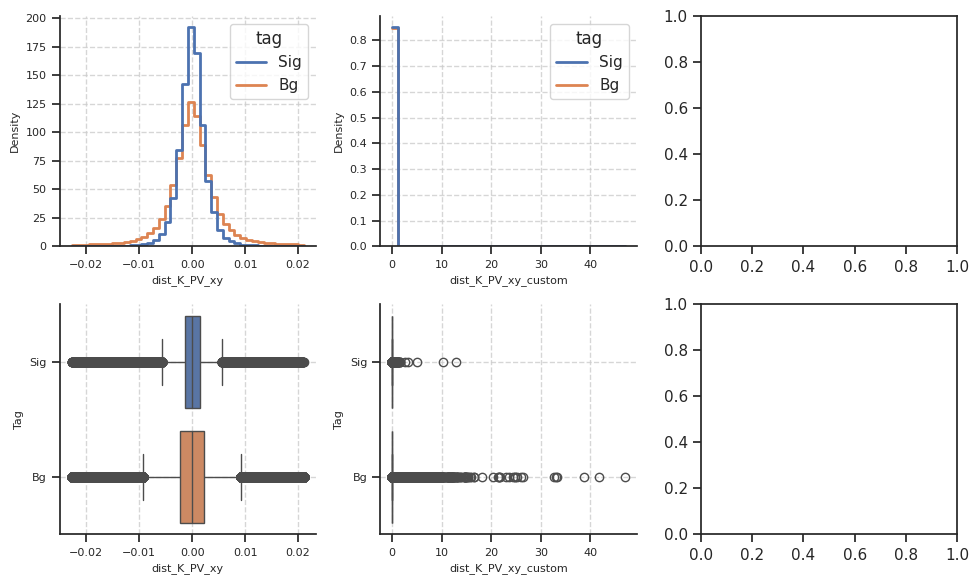

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dist_K_PV_xy', 'dist_K_PV_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=raw_df_list[0].loc[(raw_df_list[0]['dist_K_PV_xy'] < 0.0212) & (raw_df_list[0]['dist_K_PV_xy'] > -0.0228), ['dist_K_PV_xy', 'dist_K_PV_xy_custom', 'tag', 'xF']],
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()


SUMMARY STATISTICS
Total Signal Events: 20873525
Total Background Events: 1422220960241
Total Signal Events Unscaled: 102255
Total Background Events Unscaled: 469260
Overall S/B Ratio: 0.000015
Overall S/sqrt(S+B) Significance: 17.50


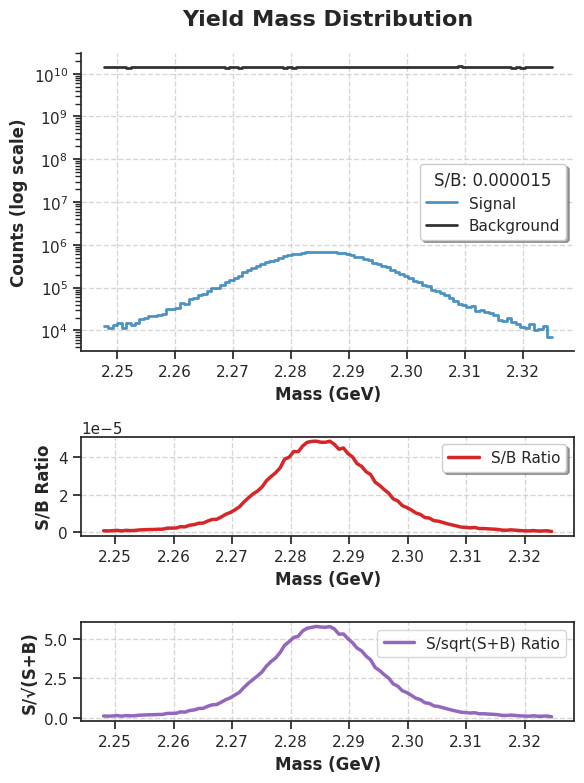

In [10]:
sig_mass_distr = raw_df_list[0].loc[raw_df_list[0]['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = raw_df_list[0].loc[raw_df_list[0]['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1,
    have_bg_events=CFG.have_bg_events_1,
    mass_interval=CFG.mass_interval, 
    visualization=True,
    verbose=True,
)

plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/mass_stats_before_selection.pdf')

# Preprocess Data

1. Preselection performs simple quantile-based selection. It cuts off all events that lie outside the quantile_left and quantile_right quantiles based on the signal distribution. The selection process begins if there are any signal events outside the interval:

    (mean - safety_range × indent; mean + safety_range × indent).

    safety_range is like quantile based safety_interval but in data range format.

2. (Removed) Select only cases where the number of tracks selected for PV reconstruction is greater than min_tracks_after_refit.

In [4]:
from analysis_scripts.selection_scripts import auto_preselection


proc_df_list = []

selection_mask_train = None

for raw_df in raw_df_list:
    
    proc_df = raw_df.copy()

    # min_tracks_after_re_fit = 7
    # proc_df = proc_df[proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit]

    features_to_select = [
        # Default features
        # 'P_p', 'P_pip', 'P_K',
        # 'eta_p', 'eta_pip', 'eta_K', 
        # 'P_Lc', 'Pt_Lc', 'eta_Lc',
        # 'Pt_p', 'Pt_K', 'Pt_pip',
        'lengthXY_Lc', 'dlengthXY_Lc', 'ctau_Lc', 
        'chi2_Lc_PV_xy', 'dist_Lc_PV_xy', 'dist_Lc_PV_xy_custom',
        'chi2_p_PV_xy', 'dist_p_PV_xy', 'dist_p_PV_xy_custom',
        'chi2_K_PV_xy', 'dist_K_PV_xy', 'dist_K_PV_xy_custom', 
        'chi2_pip_PV_xy','dist_pip_PV_xy', 'dist_pip_PV_xy_custom', 
        'chi2_p_Lc_xy','dist_p_Lc_xy', 'dist_p_Lc_xy_custom',
        'chi2_K_Lc_xy', 'dist_K_Lc_xy', 'dist_K_Lc_xy_custom',
        'chi2_pip_Lc_xy', 'dist_pip_Lc_xy', 'dist_pip_Lc_xy_custom',
        'chi2_K_pip_xy', 'dist_K_pip_xy','dist_K_pip_xy_custom',
        'chi2_p_K_xy', 'dist_p_K_xy', 'dist_p_K_xy_custom',
        'chi2_p_pip_xy', 'dist_p_pip_xy', 'dist_p_pip_xy_custom',
        'cosAngle_momentum_Lc_sum_momentum_xy', 'chi2_Lc', 'xF',
        # 'cosAngle_r_Lc_momentum_Lc_xy_left',
        # 'cosAngle_r_Lc_momentum_Lc_xy_right',
        # 'cosAngle_r_Lc_sum_momentum_xy_left',
        # 'cosAngle_r_Lc_sum_momentum_xy_right',
    ]

    quantile_dict = {}

    selection_df, mask = auto_preselection(
        df=proc_df,
        features=features_to_select,
        safety_interval=0.95,
        indent=2,
        quantile_left=1e-3,
        quantile_right=1 - 1e-3,
        recursive=True,
        quantile_dict=quantile_dict,
    )

    if selection_mask_train is None:
        proc_df = proc_df.query(mask).reset_index(drop=True)
        selection_mask_train = mask
    else:
        proc_df = proc_df.query(selection_mask_train).reset_index(drop=True)

    proc_df_copy = proc_df.copy()

    sig_eff_presel = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc'].count()
    bg_eff_presel = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].count()

    print(f'Signal efficiency: {sig_eff_presel}')
    print(f'Background Suppression: {bg_eff_presel}')
    
    cols_to_del = [
        'true_decay', 'id', 'ptOverE',
        # 'cosAngle_r_Lc_sum_momentum_xy_left', 
        # 'cosAngle_r_Lc_sum_momentum_xy_right',
        # 'cosAngle_r_Lc_momentum_Lc_xy_left',
        # 'cosAngle_r_Lc_momentum_Lc_xy_right'
    ]
    
    proc_df = proc_df.drop(columns=cols_to_del)
        
    proc_df_list.append(proc_df)

Signal efficiency: 0.9471311915238197
Background Suppression: 0.6236141088465027


In [ ]:
# proc_df_list[0].to_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_train_2.csv')
# proc_df_list[1].to_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_test_1.csv')

In [5]:
selection_df

,cut_feature,left_cut,right_cut,sig_efficiency,MB_efficiency
0,lengthXY_Lc,-0.542619,0.484482,0.997990,0.961754
1,dlengthXY_Lc,0.001495,0.048716,0.997986,0.970263
2,ctau_Lc,-0.384789,0.400450,0.997982,0.947909
3,chi2_Lc_PV_xy,-6.497214,7.935054,0.997998,0.981880
4,dist_Lc_PV_xy,-0.042966,0.048138,0.997994,0.988362
5,dist_Lc_PV_xy_custom,NaN,0.078685,0.998995,0.994891
6,chi2_p_PV_xy,-3.453170,4.001082,0.997988,0.985275
7,dist_p_PV_xy,-0.024548,0.024418,0.997984,0.988292
8,dist_p_PV_xy_custom,NaN,0.175829,0.999000,0.972460
9,chi2_K_PV_xy,-2.954194,3.050047,0.997997,0.989181


In [ ]:
from analysis_scripts.feature import FeatureClassification


feature_cl = FeatureClassification(df=proc_df, target_name=CFG.target_name, ordinal_columns=None)

# Load Processed DataFrames

In [2]:
train_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_train_2.csv').drop('Unnamed: 0', axis=1)
# test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_2.csv')

# Features 1D Distributions

#### probab_p, probab_k, probab_pip

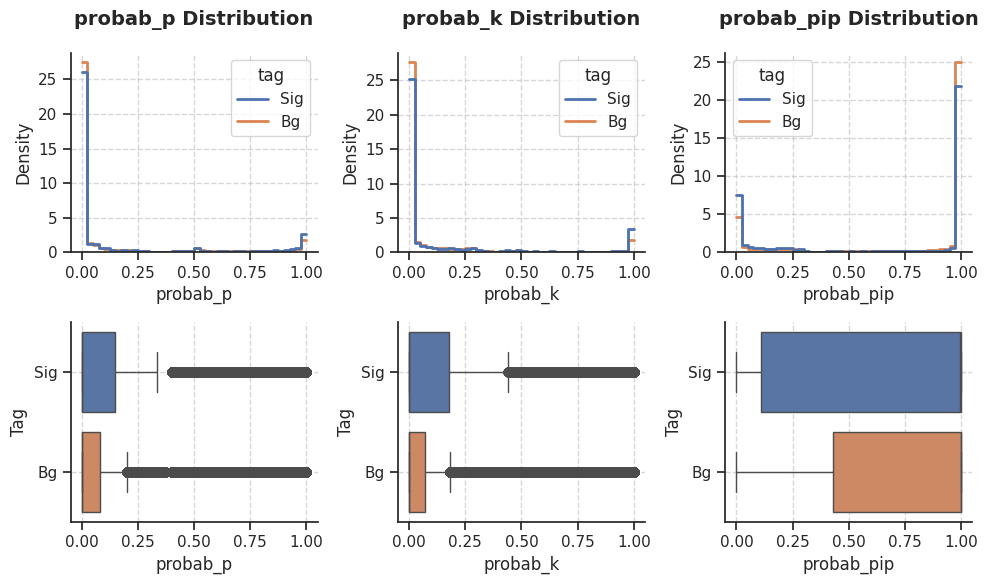

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['probab_p', 'probab_k', 'probab_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### P_p, P_K, P_pip

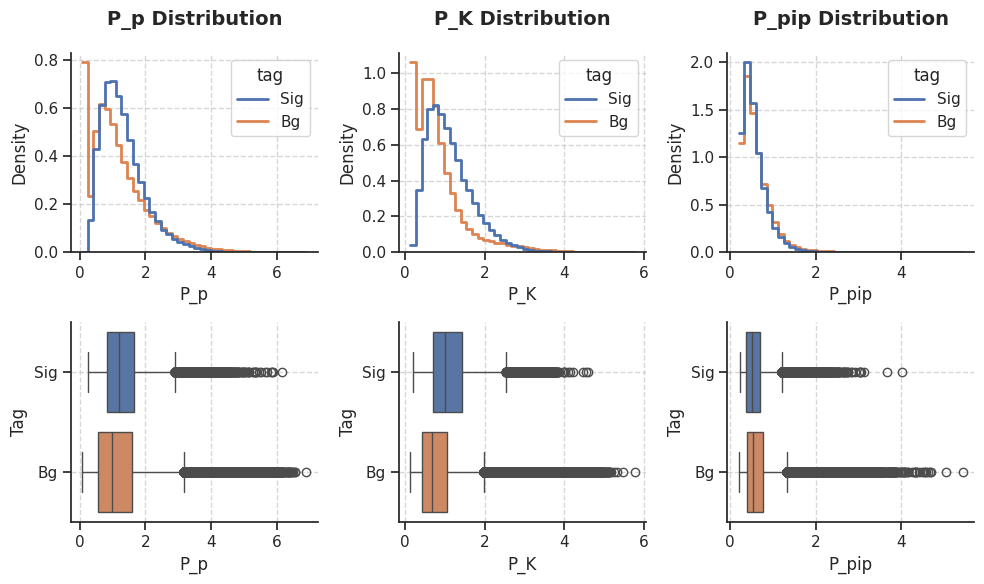

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['P_p', 'P_K', 'P_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### Pt_p, Pt_K, Pt_pip

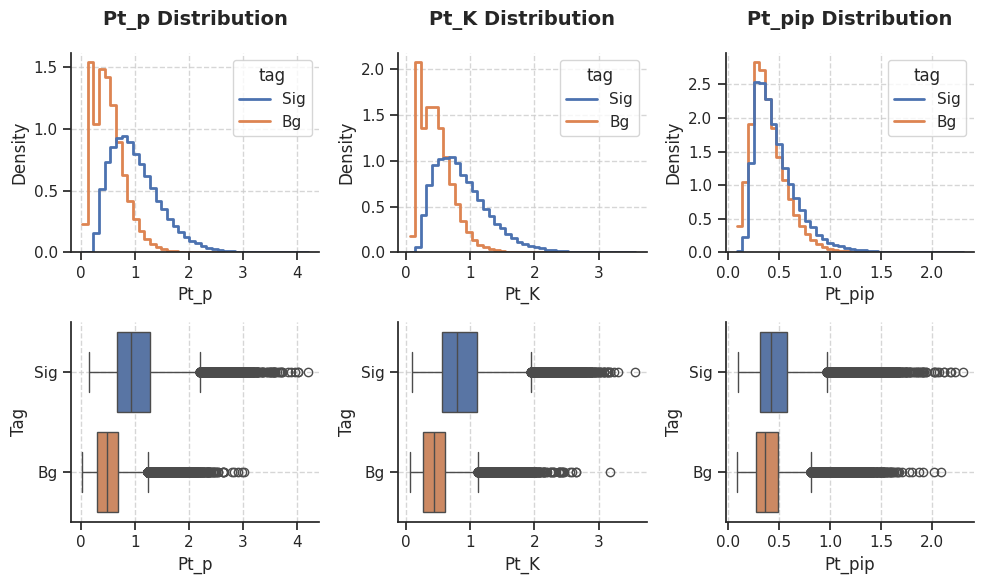

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['Pt_p', 'Pt_K', 'Pt_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### eta_p, eta_K, eta_pip

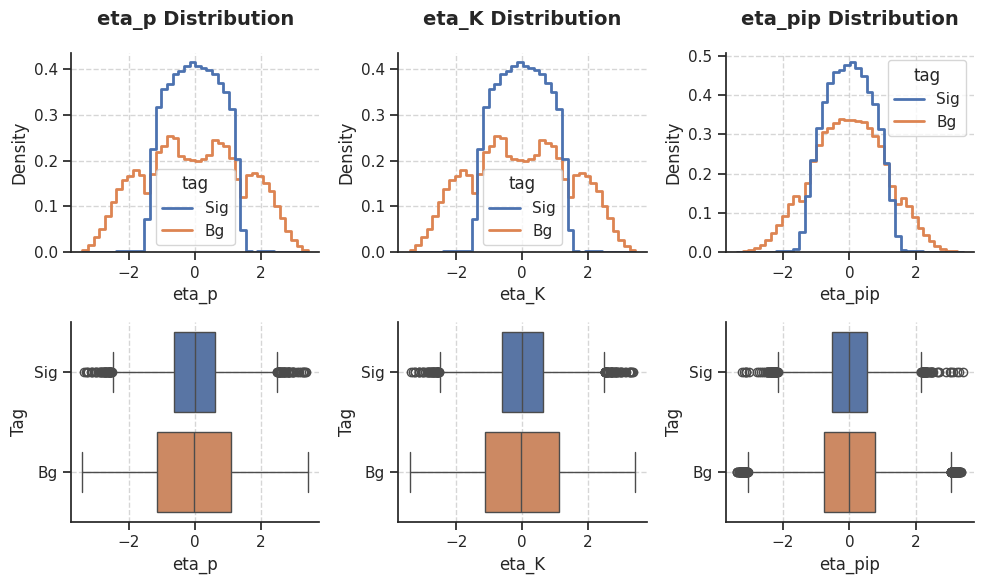

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['eta_p', 'eta_K', 'eta_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### OA_p, OA_K, OA_pip

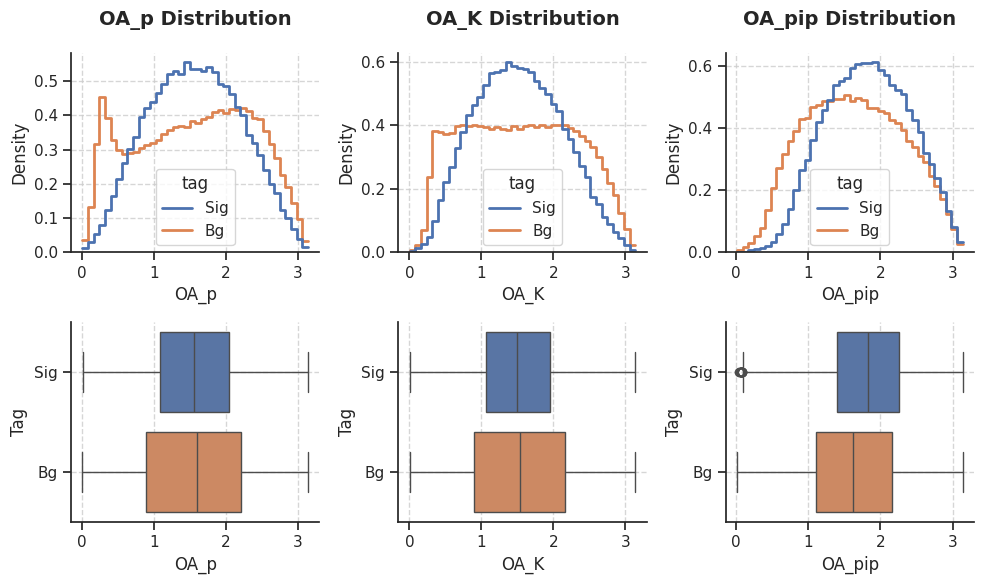

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['OA_p', 'OA_K', 'OA_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### dist_p_PV_xy, dist_K_PV_xy, dist_pip_PV_xy

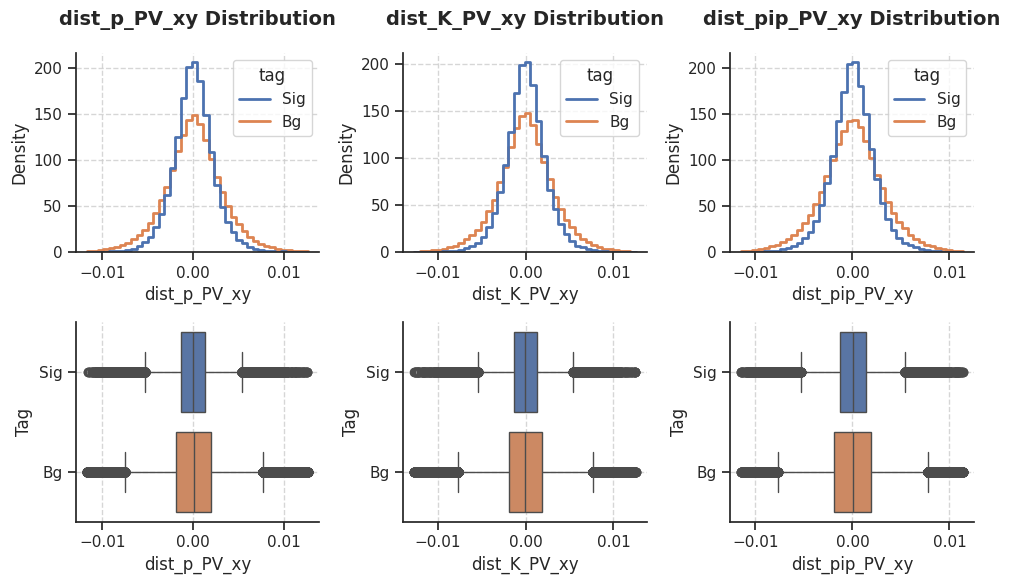

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dist_p_PV_xy', 'dist_K_PV_xy', 'dist_pip_PV_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_p_PV_xy, chi2_K_PV_xy, chi2_pip_PV_xy

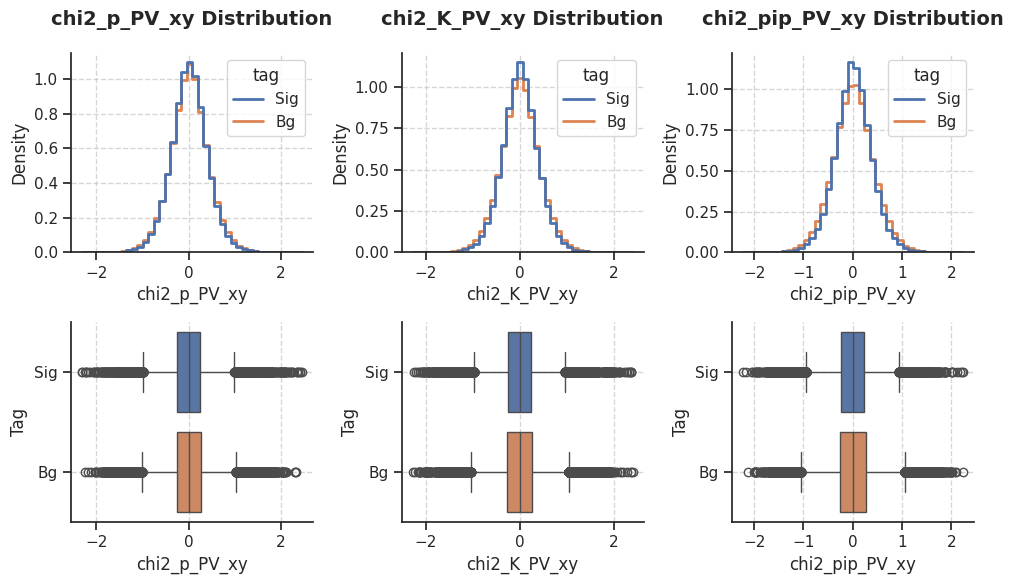

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_p_PV_xy', 'chi2_K_PV_xy', 'chi2_pip_PV_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### dist_p_PV_xy_custom, dist_K_PV_xy_custom, dist_pip_PV_xy_custom

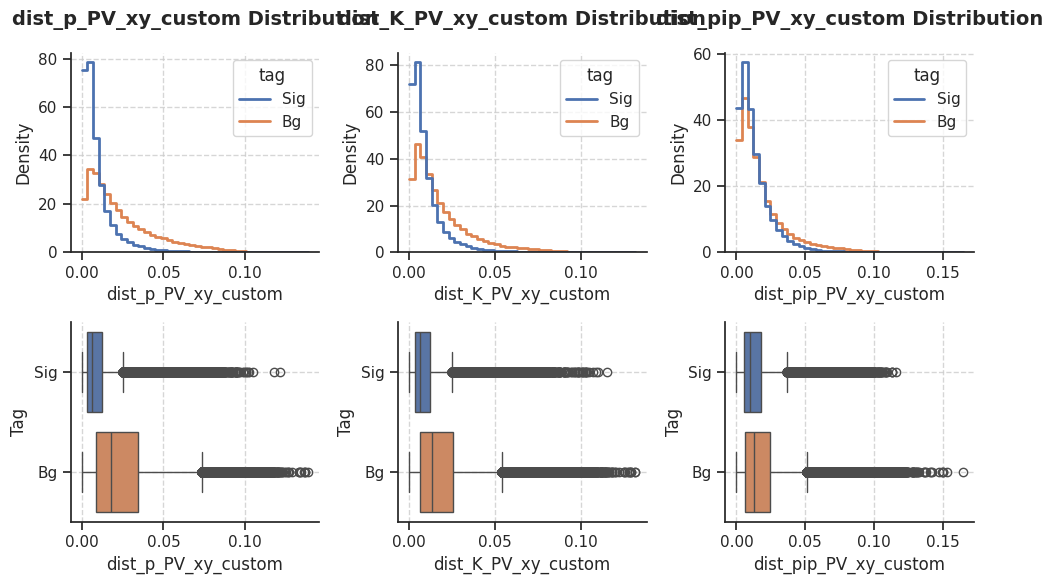

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dist_p_PV_xy_custom', 'dist_K_PV_xy_custom', 'dist_pip_PV_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### dist_p_Lc_xy_custom, dist_K_Lc_xy_custom, dist_pip_Lc_xy_custom

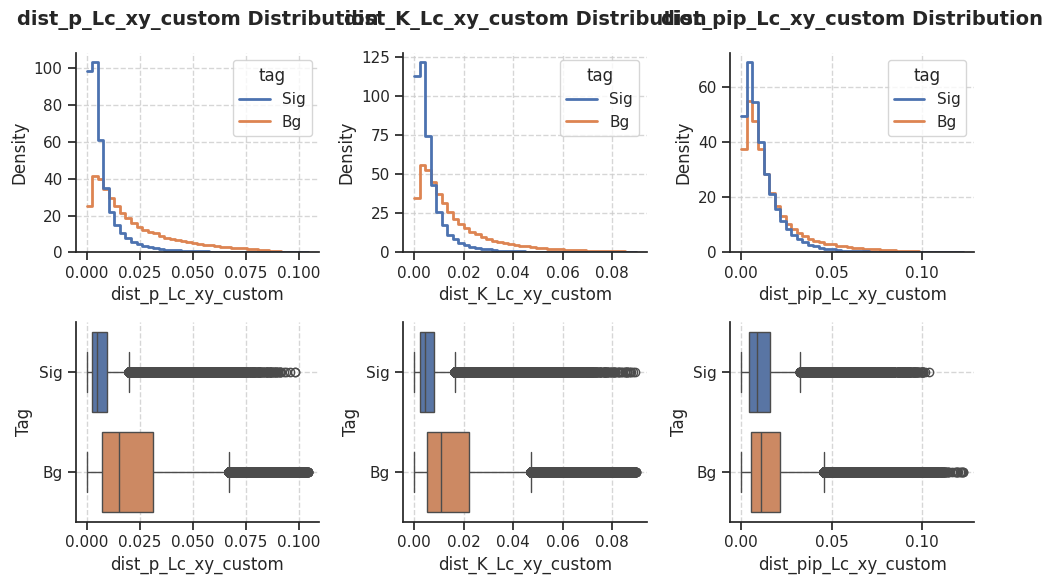

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dist_p_Lc_xy_custom', 'dist_K_Lc_xy_custom', 'dist_pip_Lc_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### dist_p_Lc_xy, dist_K_Lc_xy, dist_pip_Lc_xy

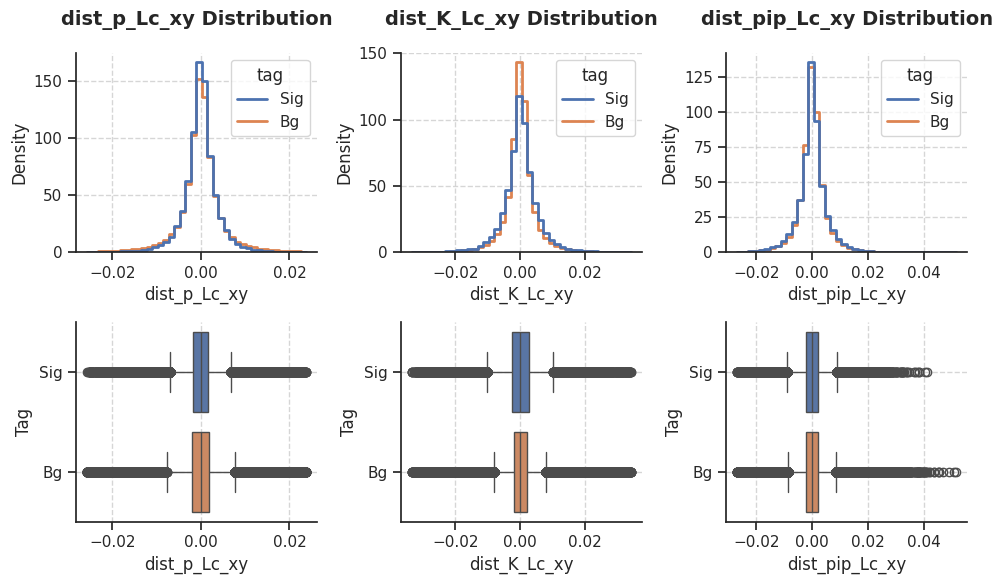

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dist_p_Lc_xy', 'dist_K_Lc_xy', 'dist_pip_Lc_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_p_Lc_xy, chi2_K_Lc_xy, chi2_pip_Lc_xy

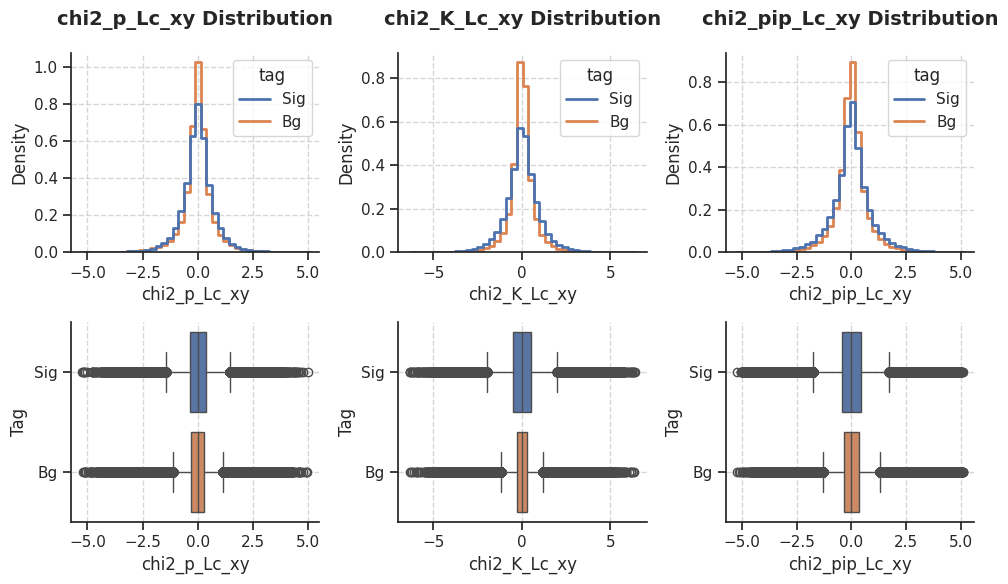

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_p_Lc_xy', 'chi2_K_Lc_xy', 'chi2_pip_Lc_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_K_pip_xy, dist_K_pip_xy, dist_K_pip_xy_custom

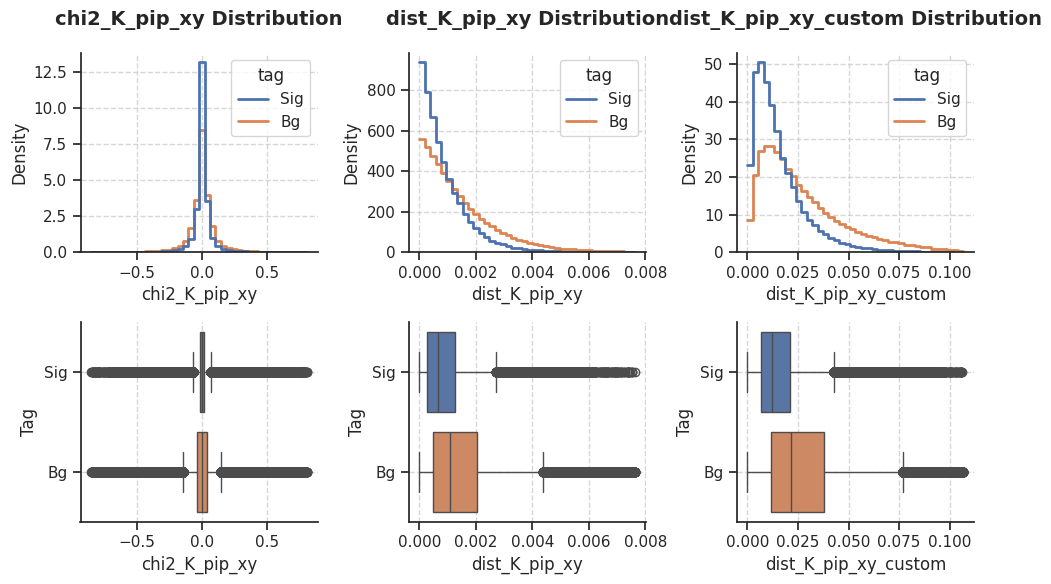

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_K_pip_xy', 'dist_K_pip_xy', 'dist_K_pip_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_p_K_xy, dist_p_K_xy, dist_p_K_xy_custom

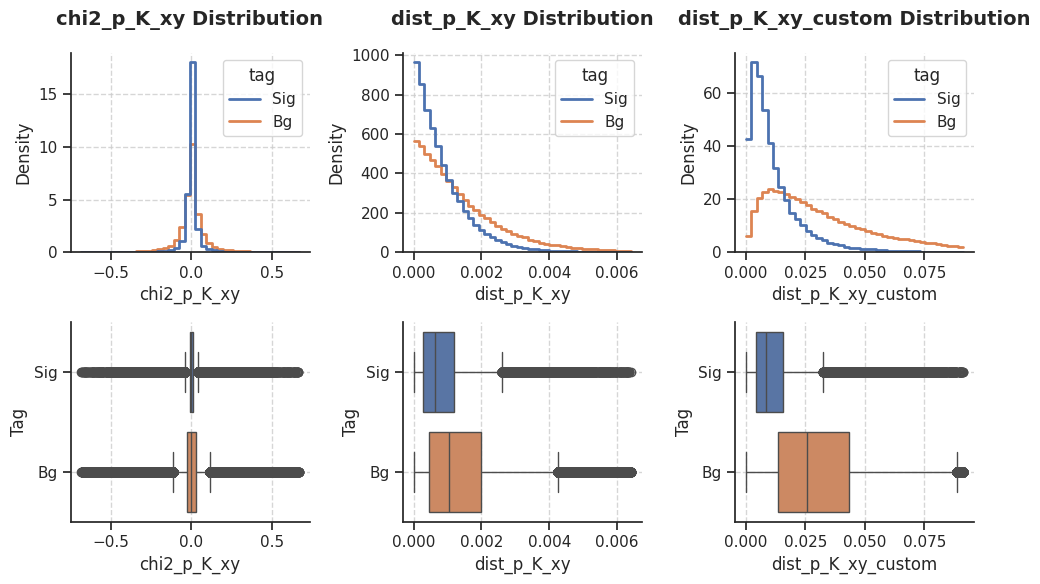

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_p_K_xy', 'dist_p_K_xy', 'dist_p_K_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_p_pip_xy, dist_p_pip_xy, dist_p_pip_xy_custom

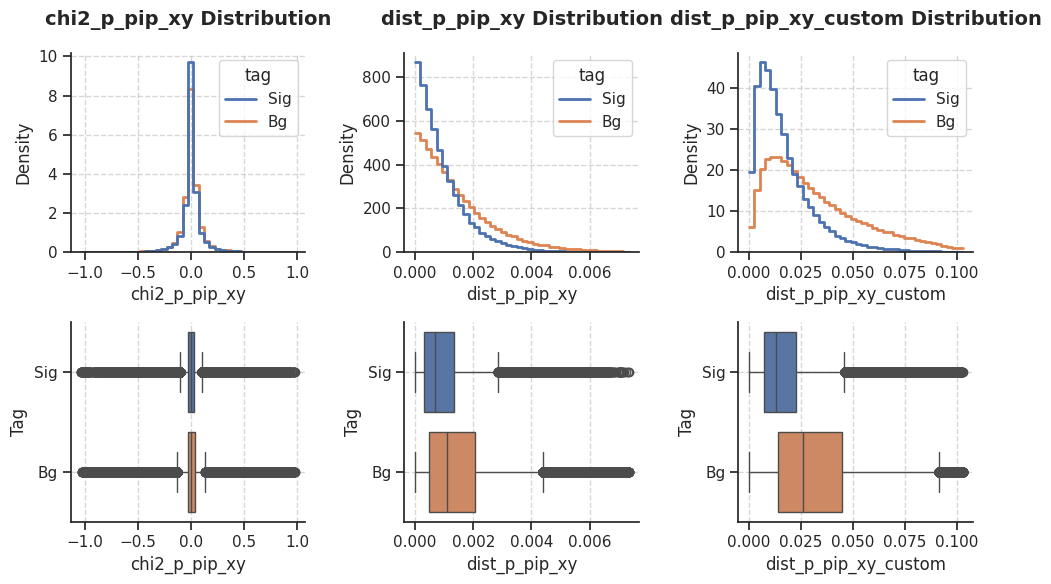

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_p_pip_xy', 'dist_p_pip_xy', 'dist_p_pip_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### cosAngle_r_Lc_momentum_Lc_xy, cosAngle_r_Lc_sum_momentum_xy, cosAngle_momentum_Lc_sum_momentum_xy

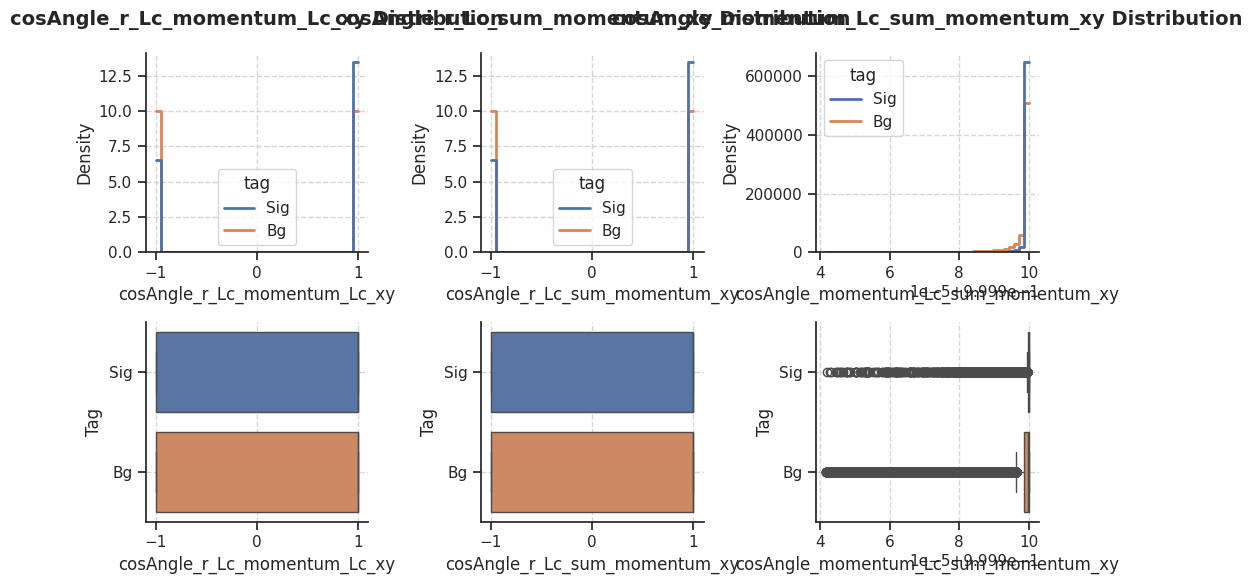

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['cosAngle_r_Lc_momentum_Lc_xy', 'cosAngle_r_Lc_sum_momentum_xy', 'cosAngle_momentum_Lc_sum_momentum_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### xF, phi_angle, multiplicity

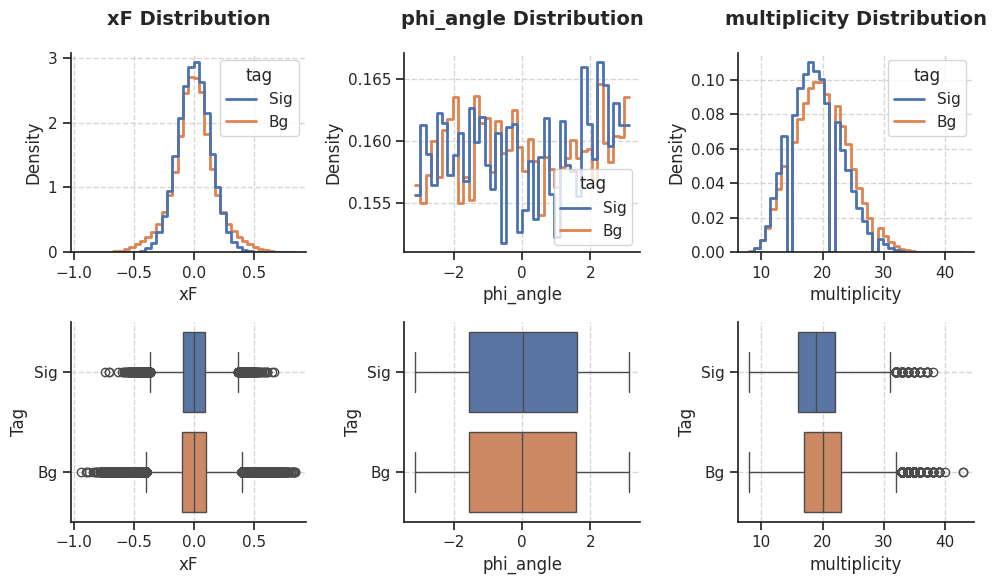

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['xF', 'phi_angle', 'multiplicity']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### P_Lc, Pt_Lc, eta_Lc

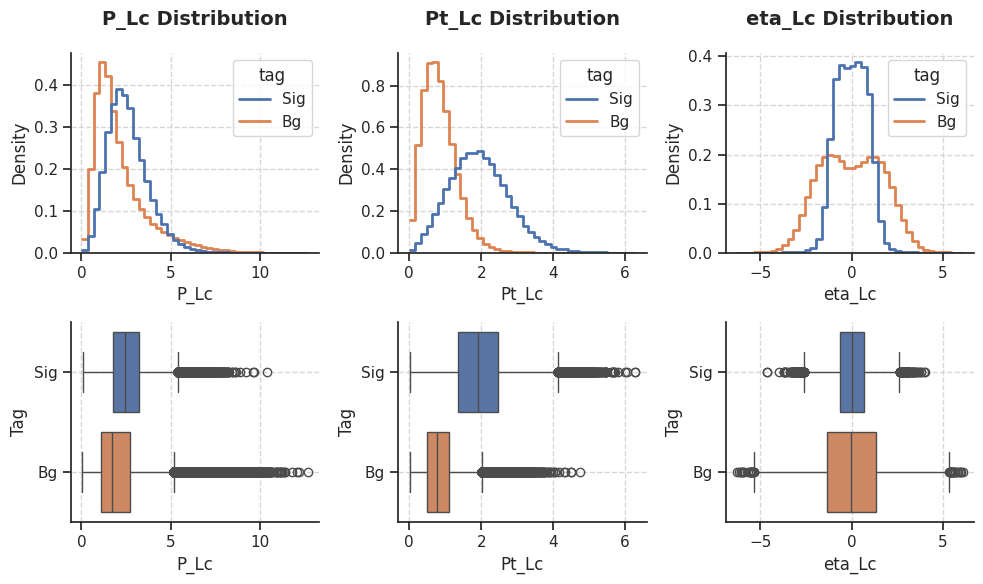

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['P_Lc', 'Pt_Lc', 'eta_Lc']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_Lc_PV_xy, dist_Lc_PV_xy, dist_Lc_PV_xy_custom

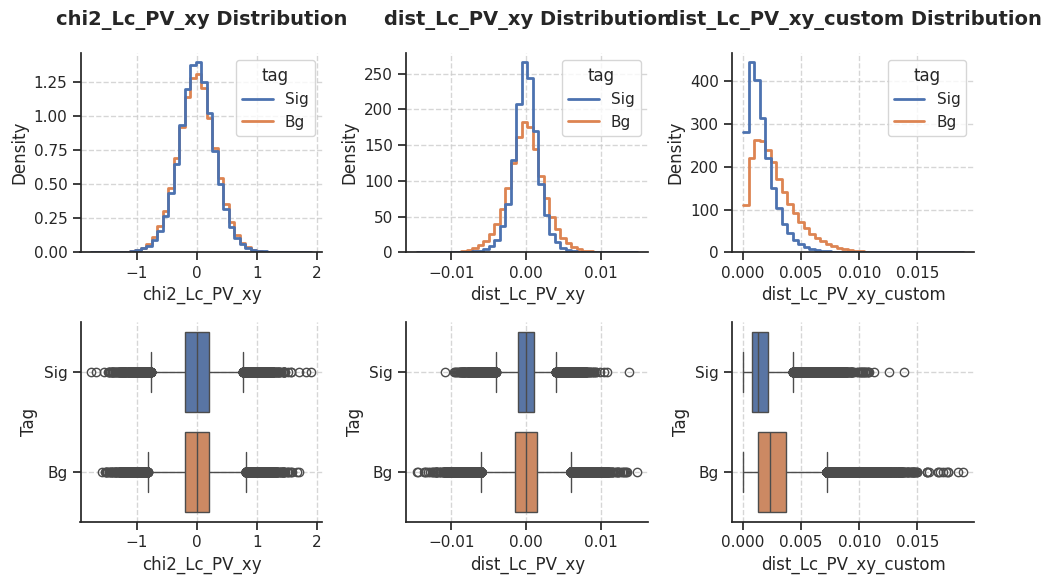

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_Lc_PV_xy', 'dist_Lc_PV_xy', 'dist_Lc_PV_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### lengthXY_Lc, dlengthXY_Lc, l_over_dl_XY

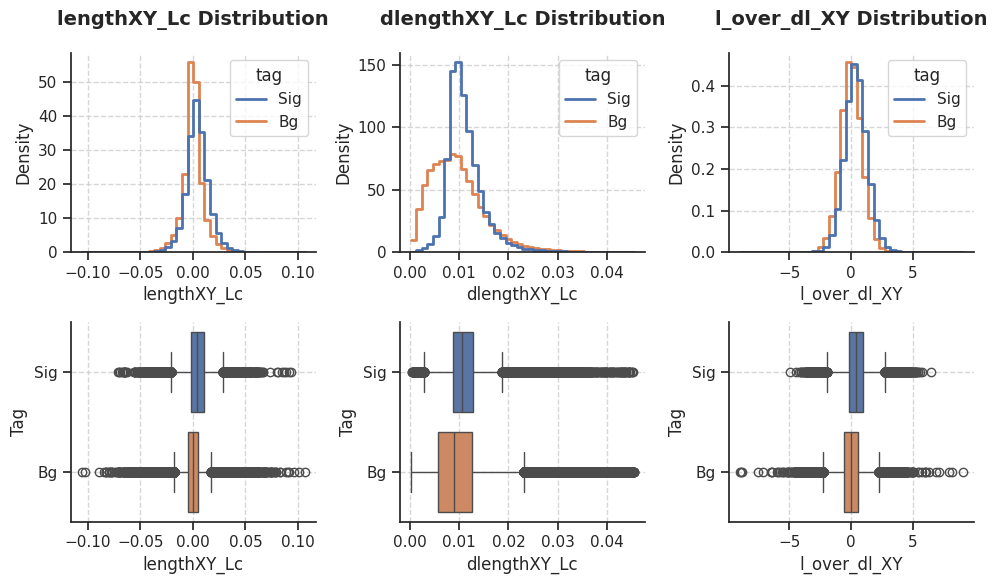

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['lengthXY_Lc', 'dlengthXY_Lc', 'l_over_dl_XY']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### ctau_Lc

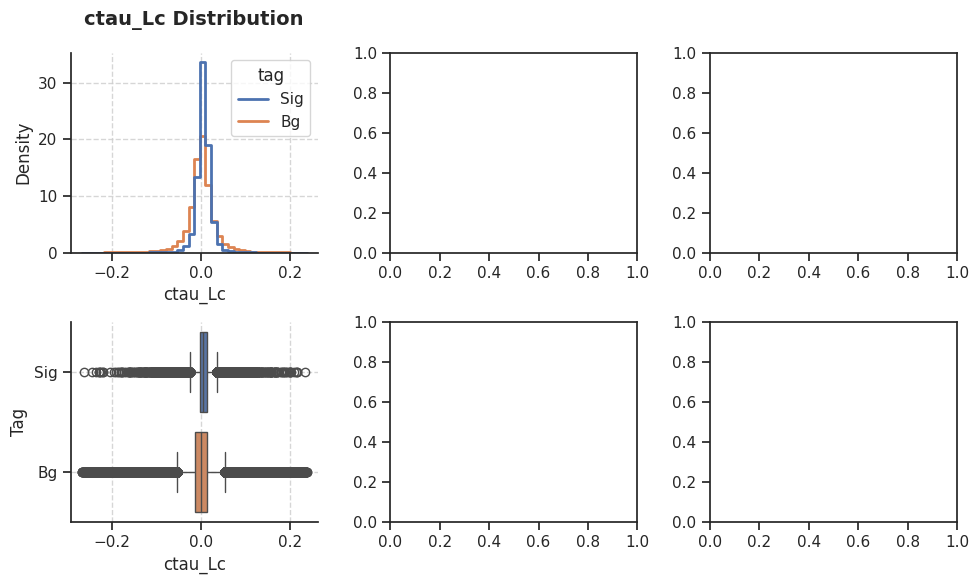

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['ctau_Lc']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### chi2_Lc

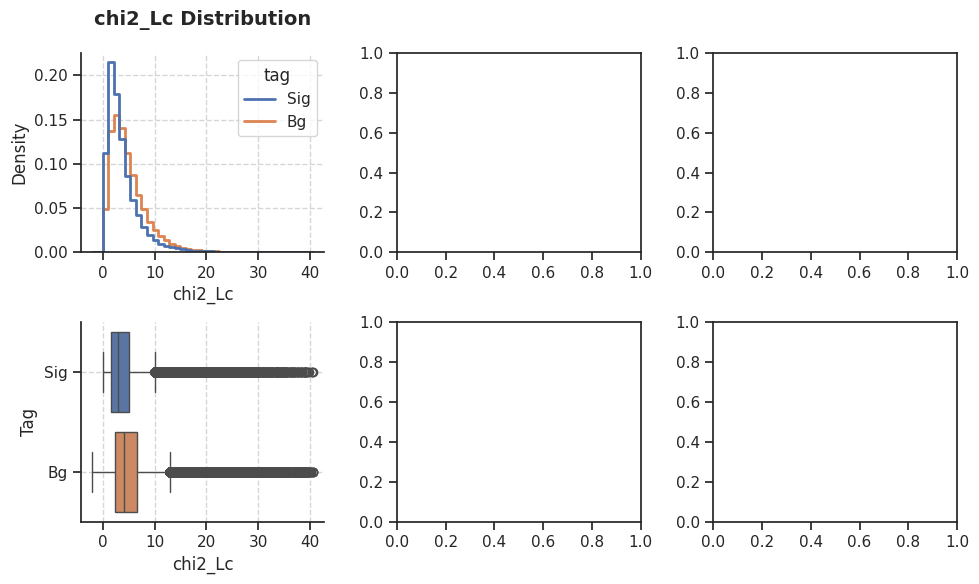

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['chi2_Lc']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### mass_Lc, mass_significance, mass_pt_correlation

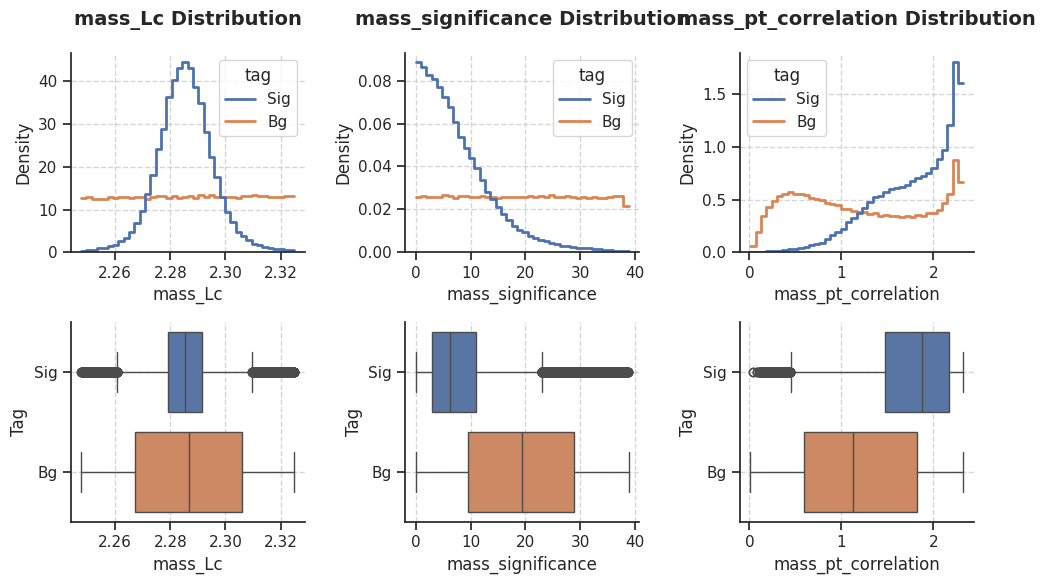

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['mass_Lc', 'mass_significance', 'mass_pt_correlation']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_pv_significance, K_pv_significance, pip_pv_significance

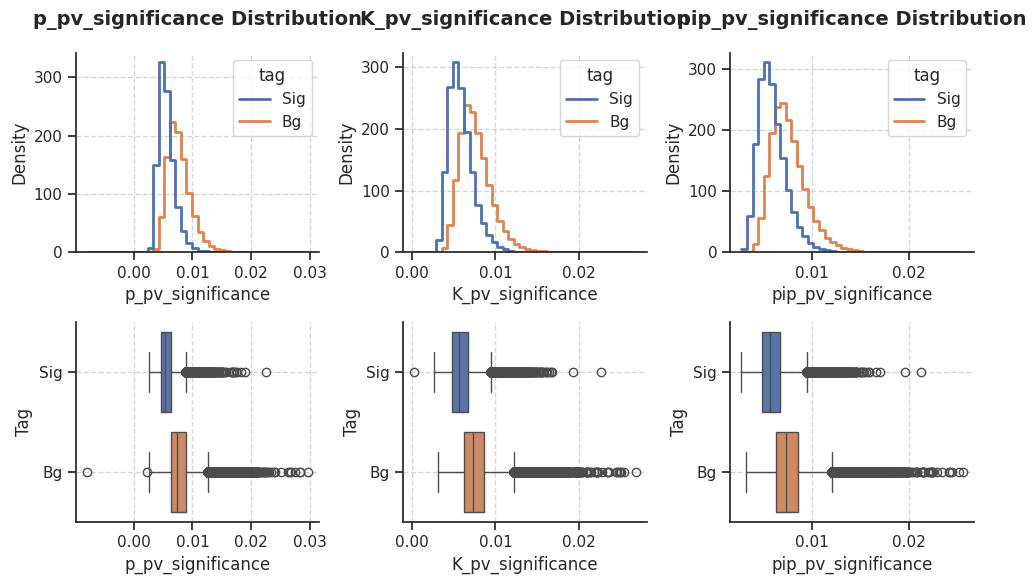

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_pv_significance', 'K_pv_significance', 'pip_pv_significance']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_momentum_ratio, pip_momentum_ratio, K_momentum_ratio

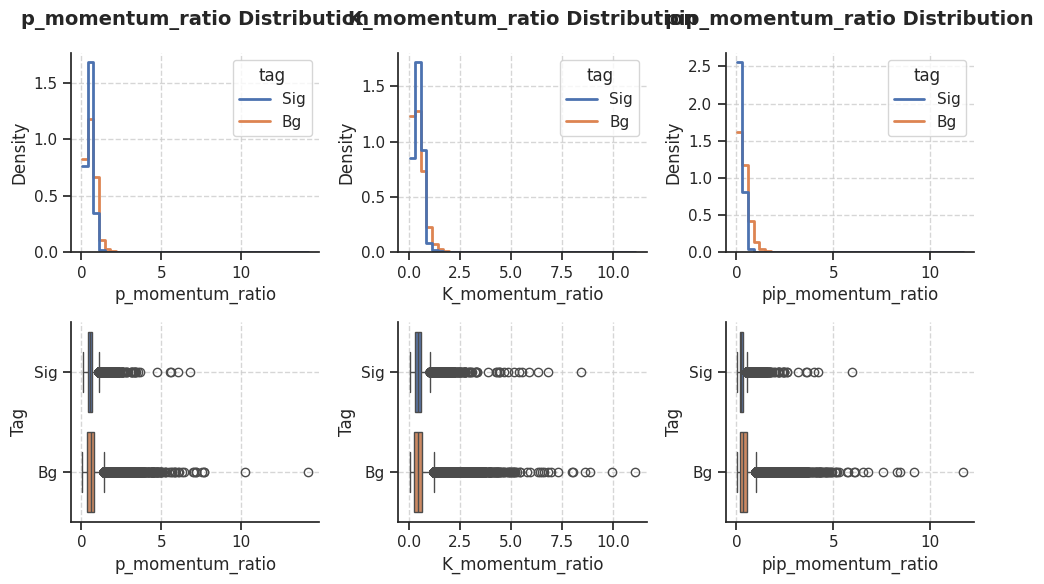

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_momentum_ratio', 'K_momentum_ratio', 'pip_momentum_ratio']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_Pt_fraction, K_Pt_fraction, pip_Pt_fraction

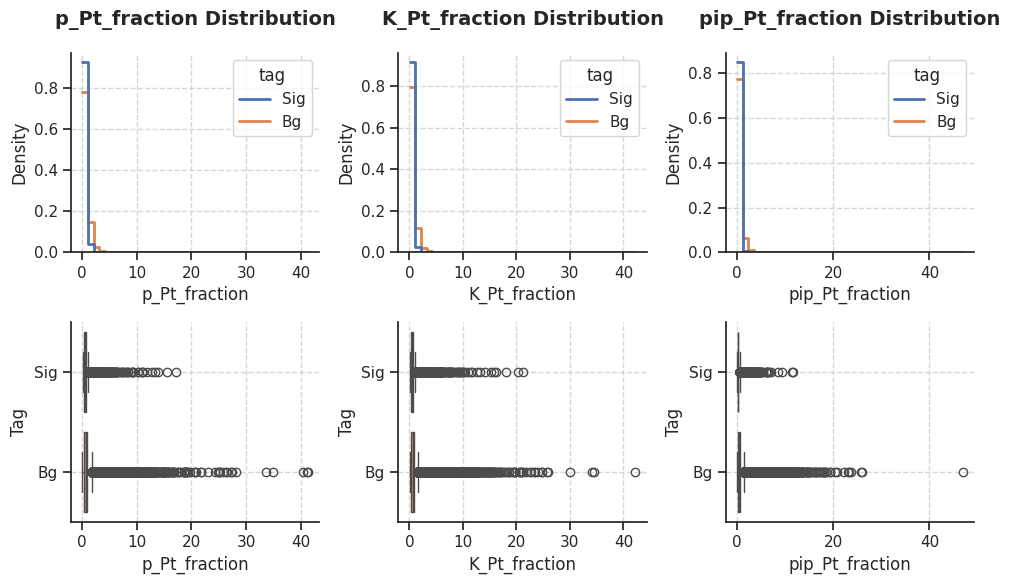

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_Pt_fraction', 'K_Pt_fraction', 'pip_Pt_fraction']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### delta_eta_p, delta_eta_K, delta_eta_pip

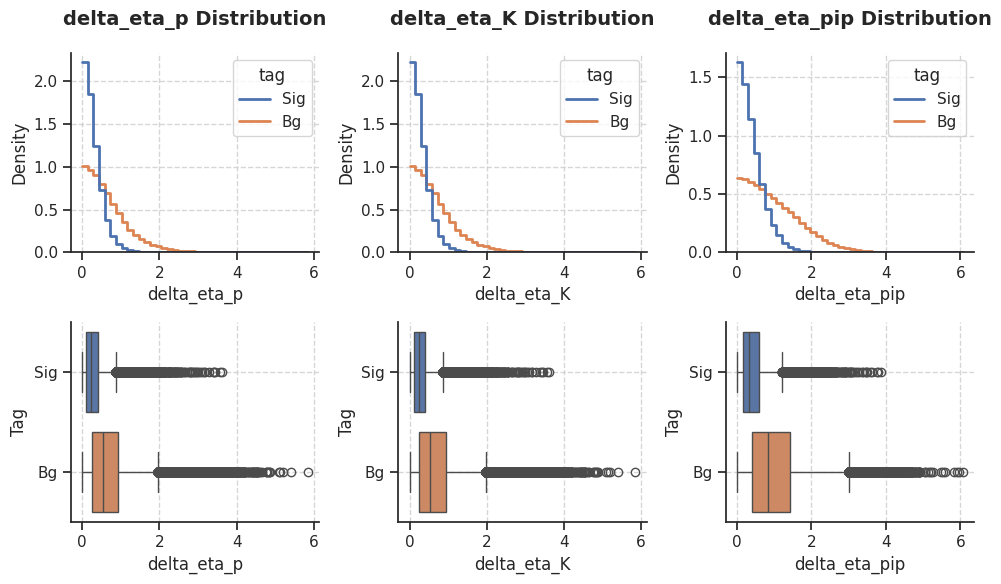

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['delta_eta_p', 'delta_eta_K', 'delta_eta_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_displacement_ratio, K_displacement_ratio, pip_displacement_ratio

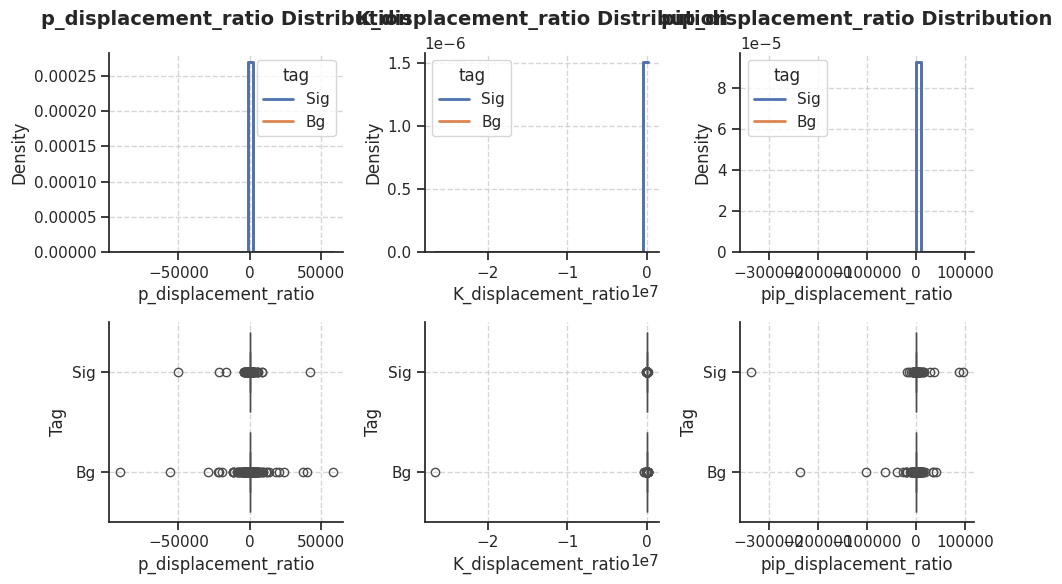

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_displacement_ratio', 'K_displacement_ratio', 'pip_displacement_ratio']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### topology_score

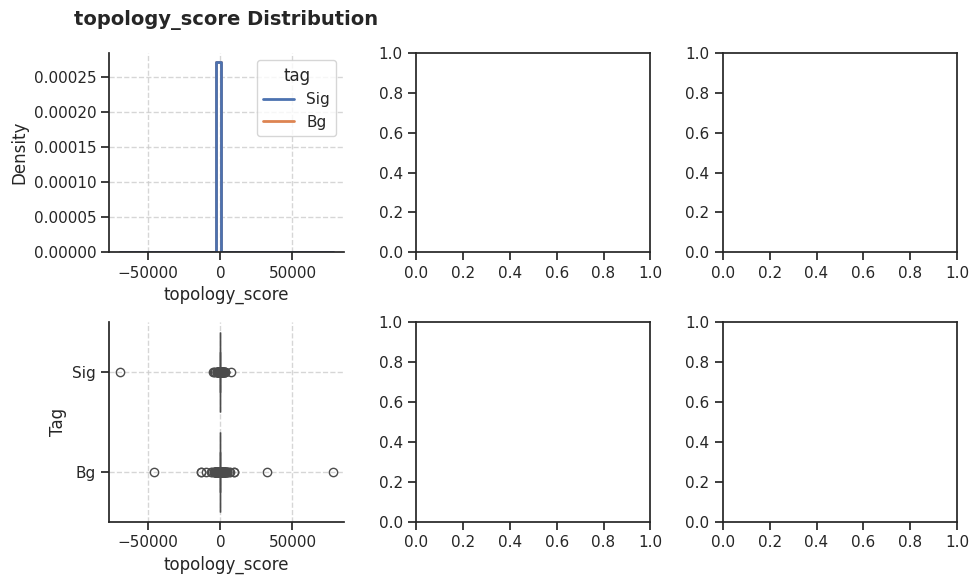

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['topology_score']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### E_p, E_K, E_pip

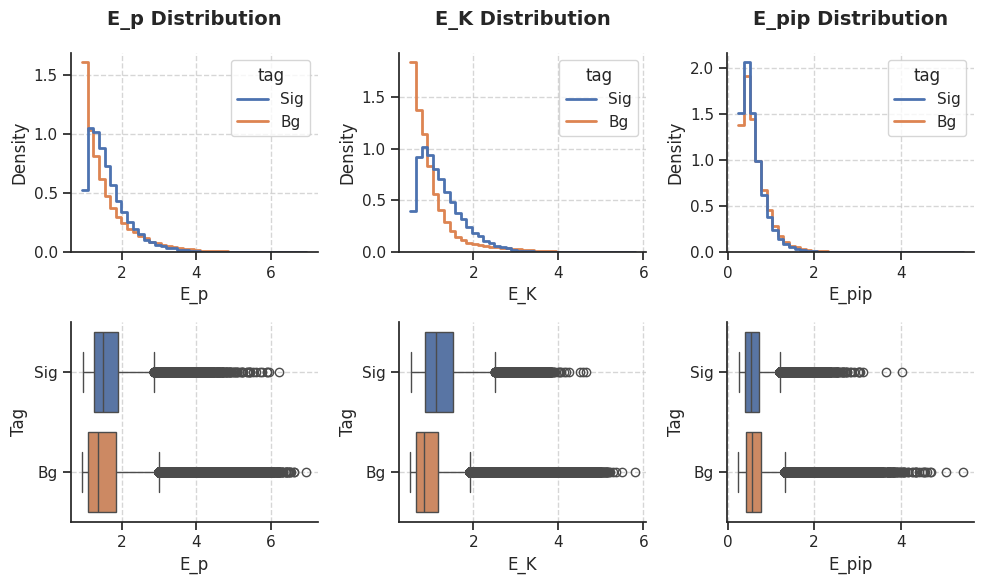

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['E_p', 'E_K', 'E_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### E_total, pt_over_E, Mt_Lc

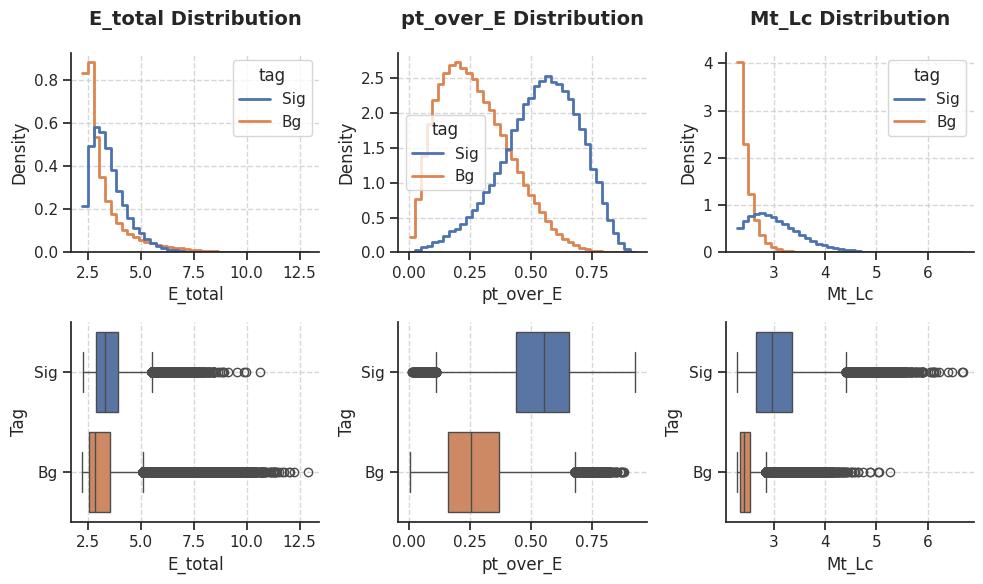

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['E_total', 'pt_over_E', 'Mt_Lc']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### opening_angle_sum, opening_angle_product, lifetime_opening_interaction

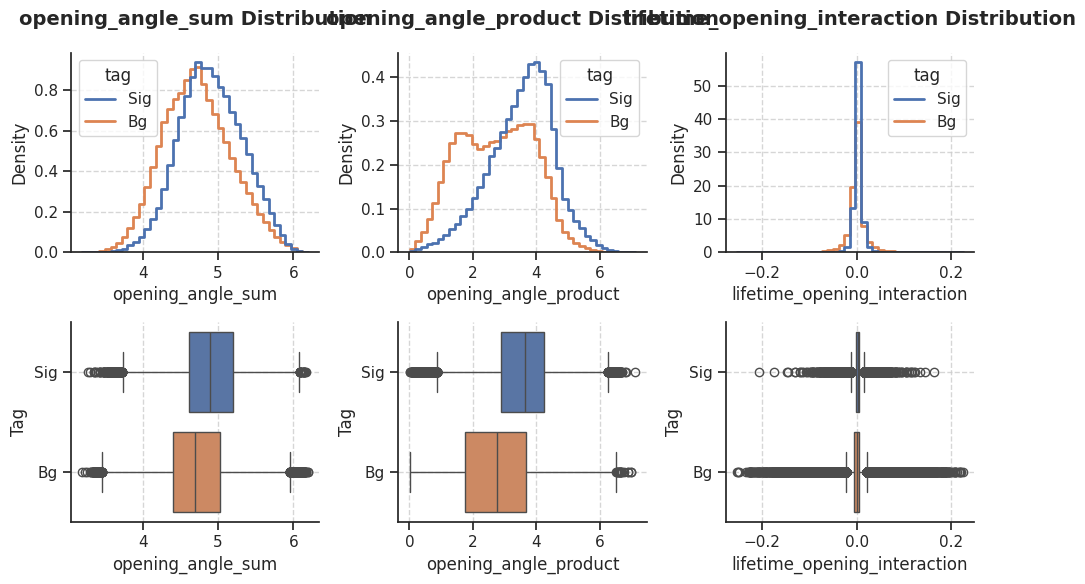

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['opening_angle_sum', 'opening_angle_product', 'lifetime_opening_interaction']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### Mt_p, Mt_K, Mt_pip

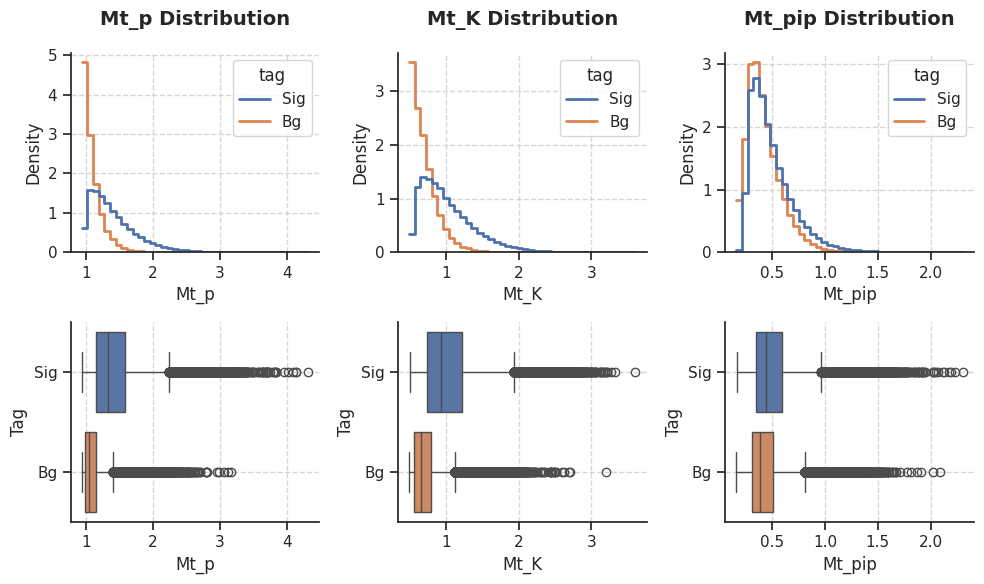

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['Mt_p', 'Mt_K', 'Mt_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### energy_asymmetry_pK, energy_asymmetry_ppip, energy_asymmetry_Kpip

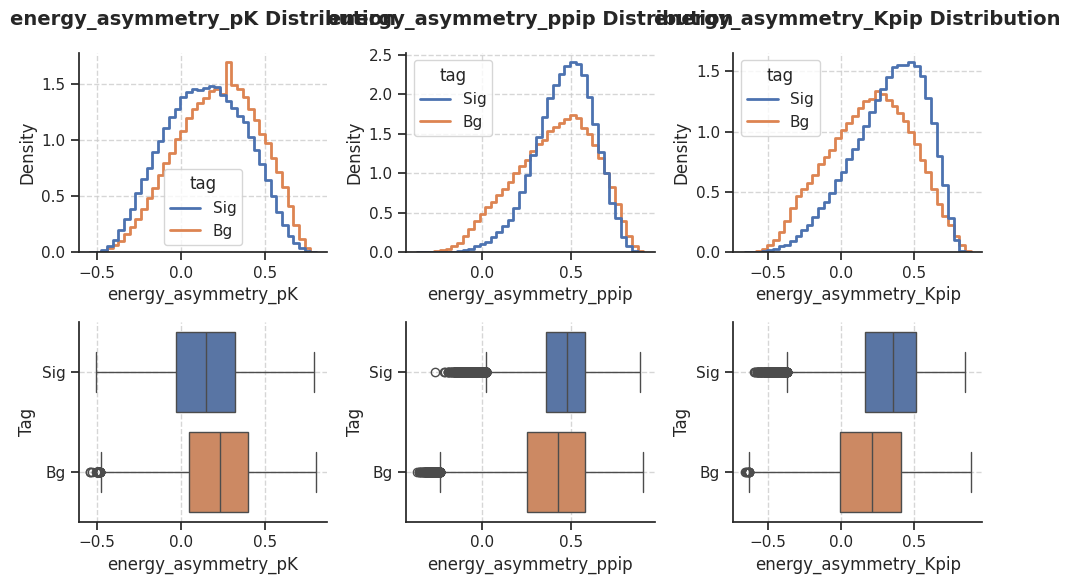

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['energy_asymmetry_pK', 'energy_asymmetry_ppip', 'energy_asymmetry_Kpip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### alignment_score

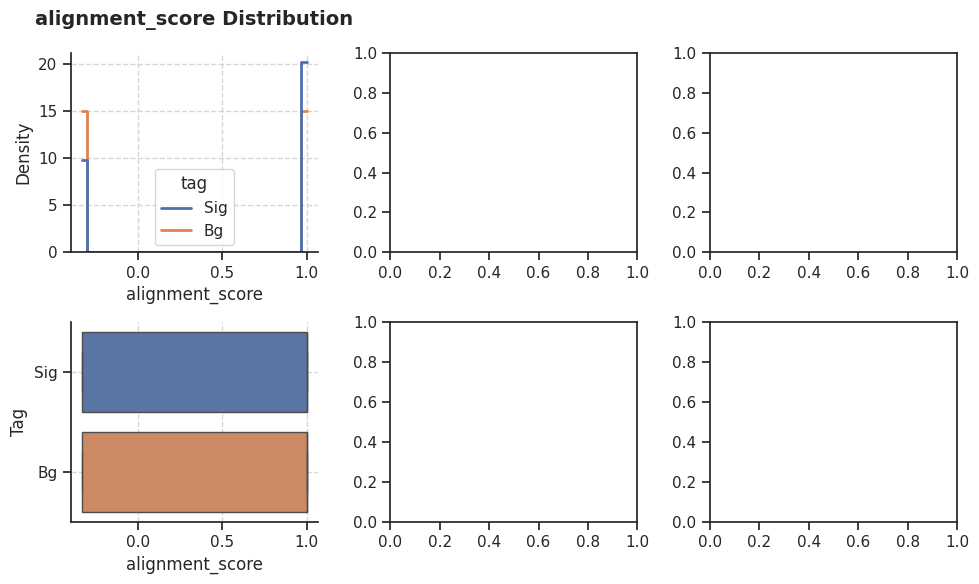

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['alignment_score']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### rapidity_p, rapidity_K, rapidity_pip (check formula -> no Pz sign)

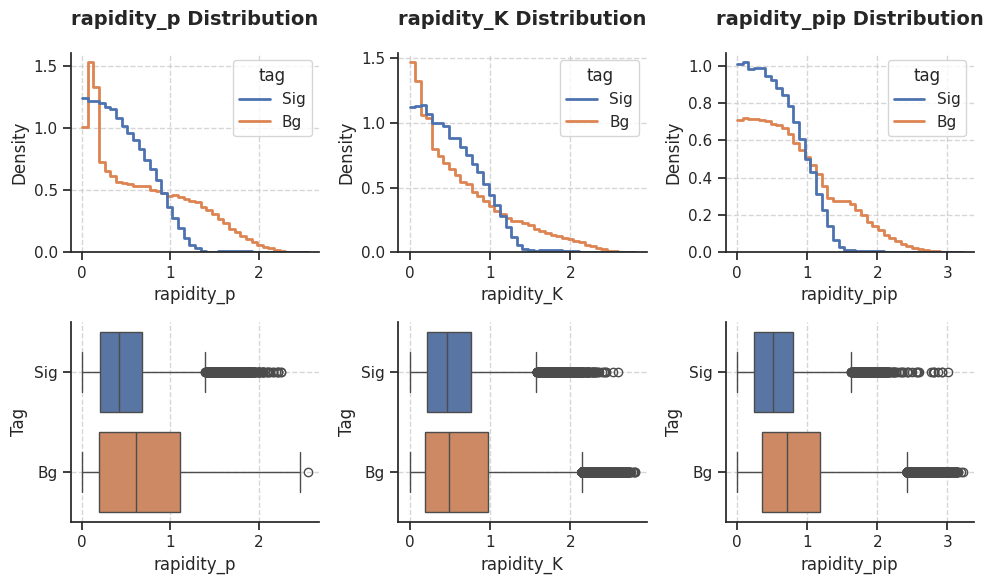

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['rapidity_p', 'rapidity_K', 'rapidity_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### P_p_over_P_K, P_p_over_P_pip, P_K_over_P_pip

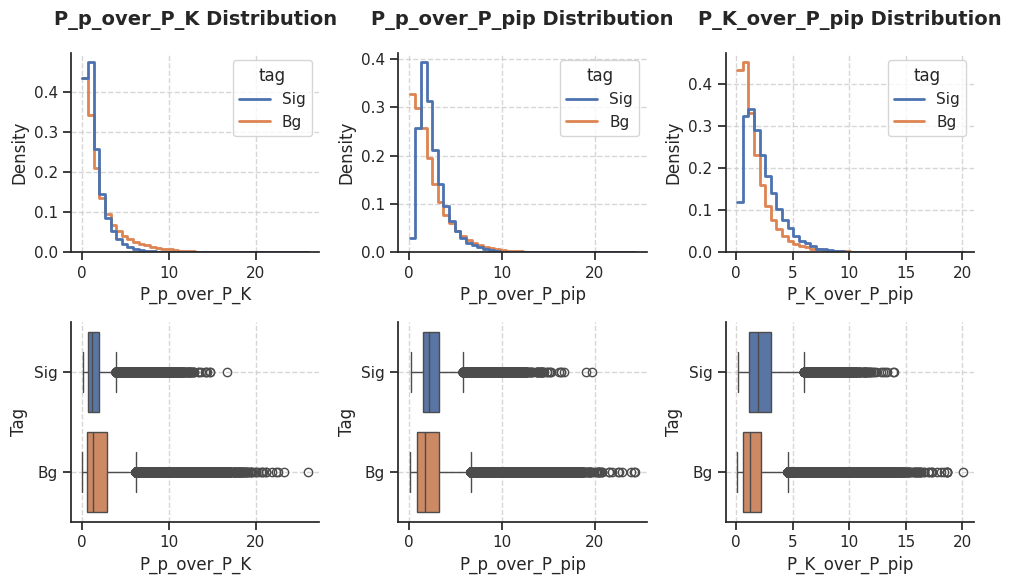

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['P_p_over_P_K', 'P_p_over_P_pip', 'P_K_over_P_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### Pt_p_over_Pt_K, Pt_p_over_Pt_pip, Pt_K_over_Pt_pi

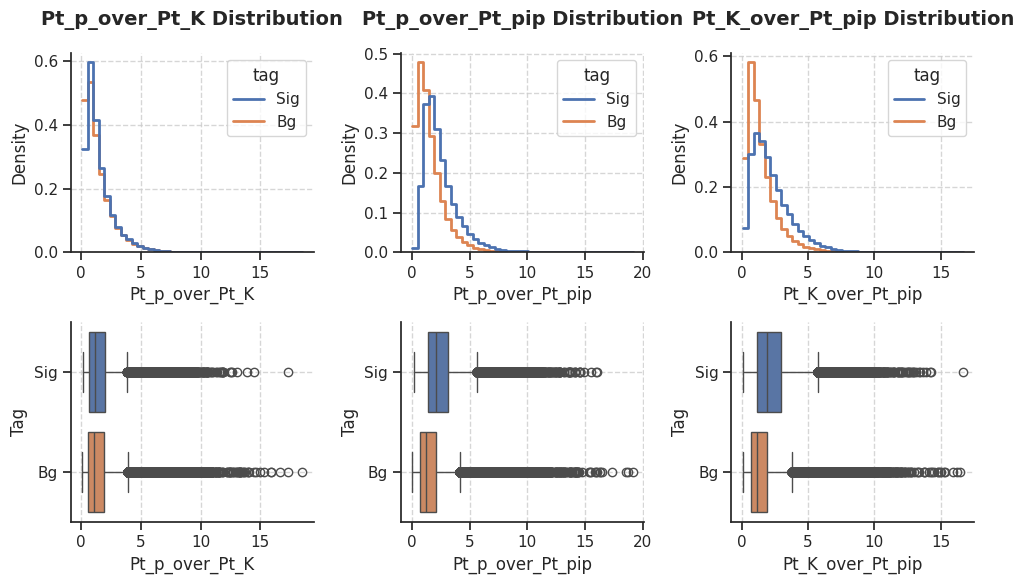

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['Pt_p_over_Pt_K', 'Pt_p_over_Pt_pip', 'Pt_K_over_Pt_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### sum_squares_p, sum_squares_pt, sum_squares_OA

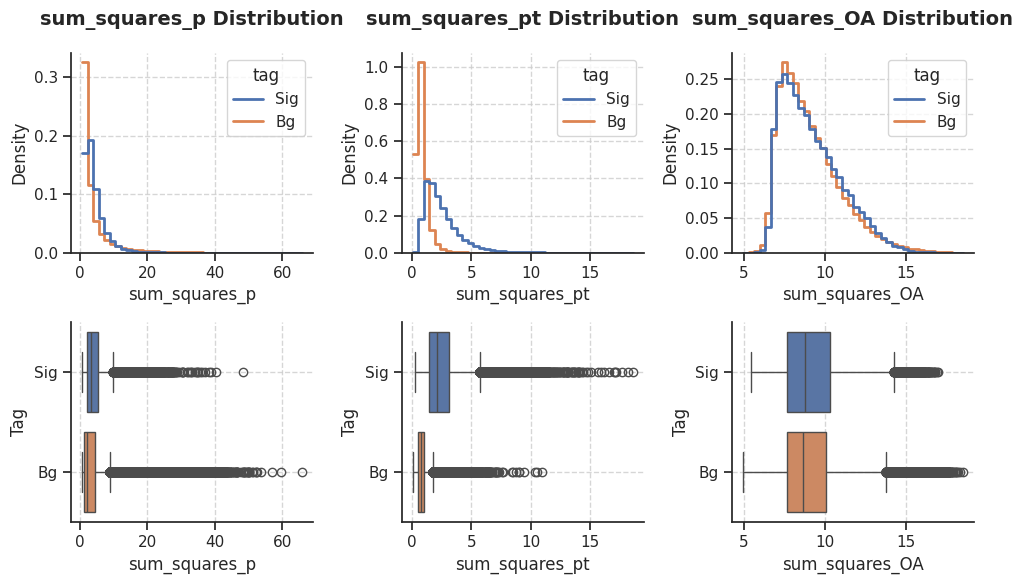

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['sum_squares_p', 'sum_squares_pt', 'sum_squares_OA']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### vertex_consistency, momentum_balance

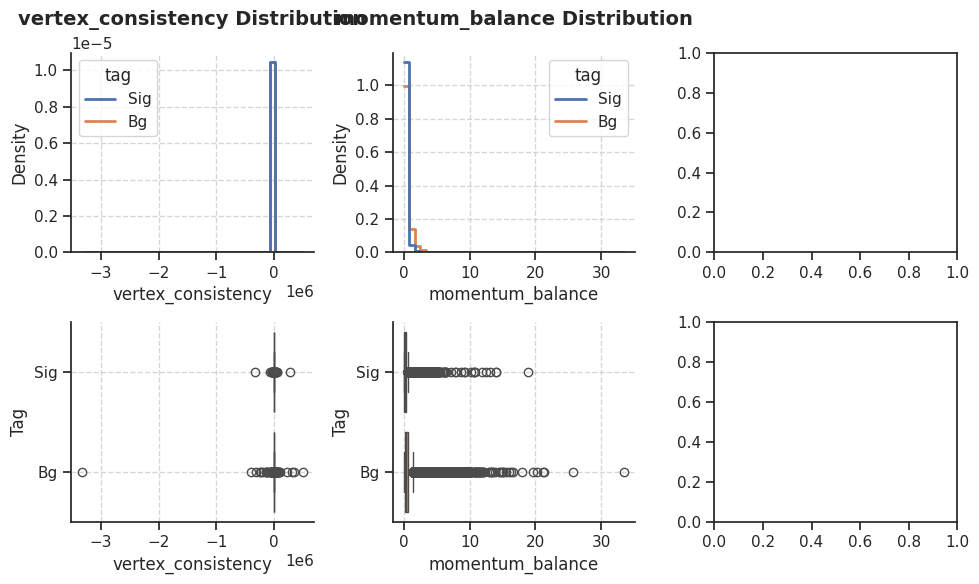

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['vertex_consistency', 'momentum_balance']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### OA_p_ratio, OA_K_ratio, OA_pip_ratio

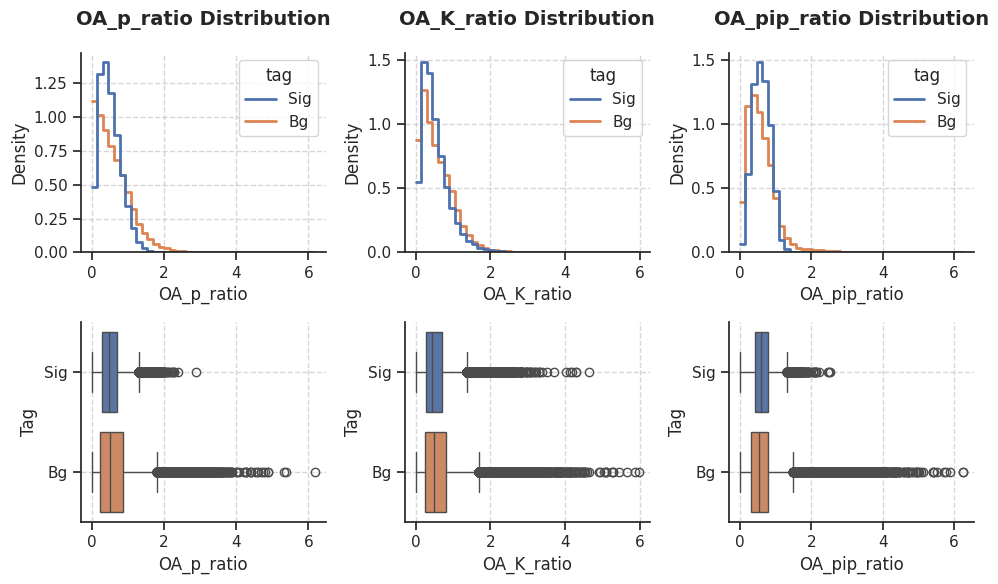

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['OA_p_ratio', 'OA_K_ratio', 'OA_pip_ratio']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### pt_over_ctau, pt_over_length

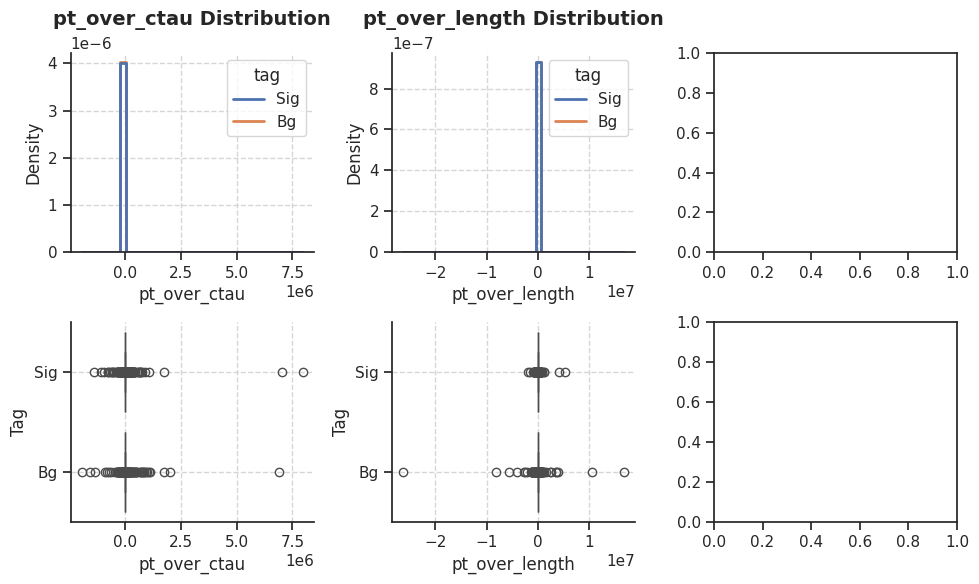

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['pt_over_ctau', 'pt_over_length']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### pt_p_times_OA_p, pt_K_times_OA_K, pt_pip_times_OA_pip

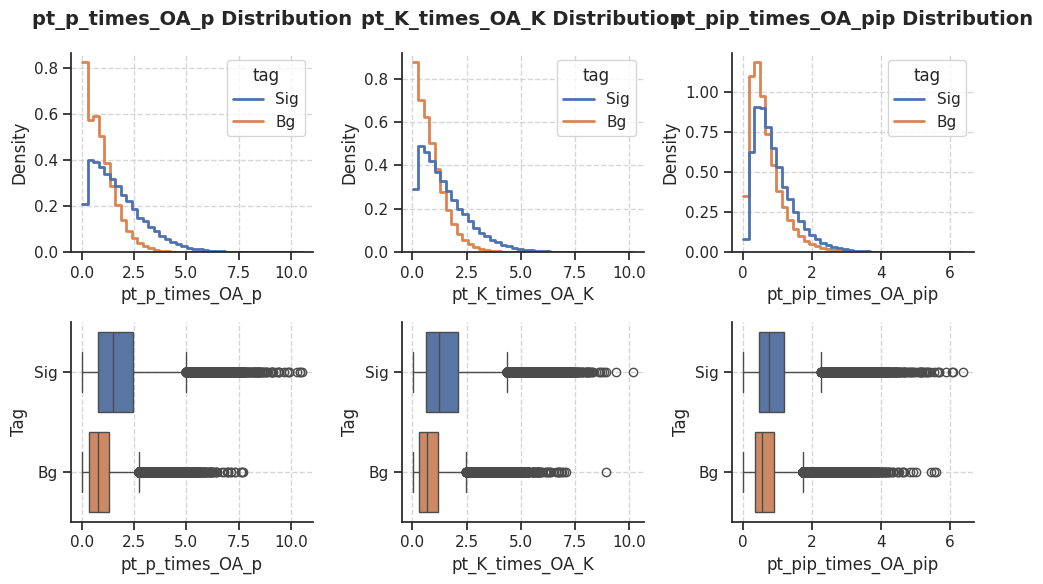

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['pt_p_times_OA_p', 'pt_K_times_OA_K', 'pt_pip_times_OA_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### triple_product

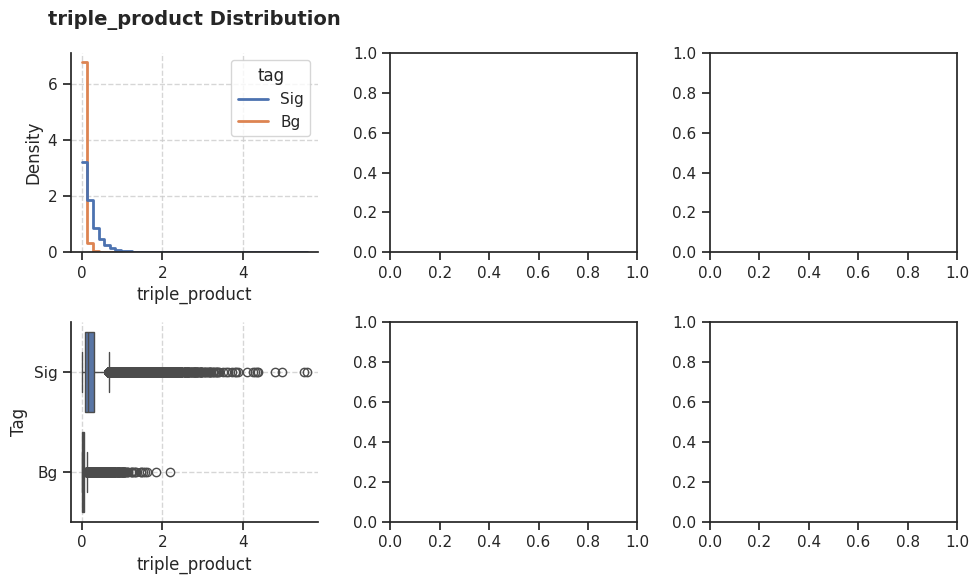

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['triple_product']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### pt_asymmetry_p_K, pt_asymmetry_p_pip, pt_asymmetry_K_pip

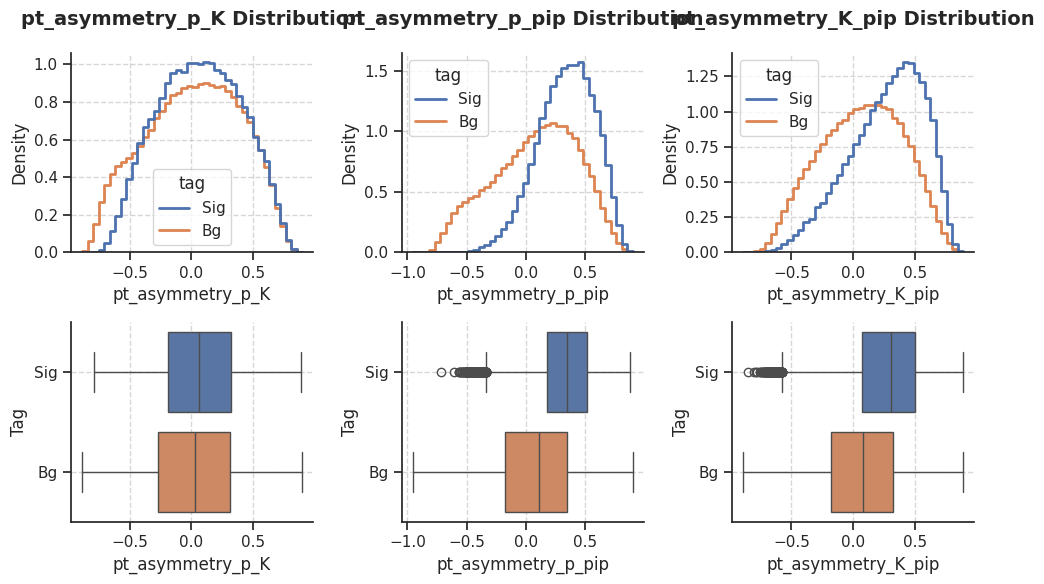

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['pt_asymmetry_p_K', 'pt_asymmetry_p_pip', 'pt_asymmetry_K_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### asymmetry_p_K, asymmetry_p_pip, asymmetry_K_pip

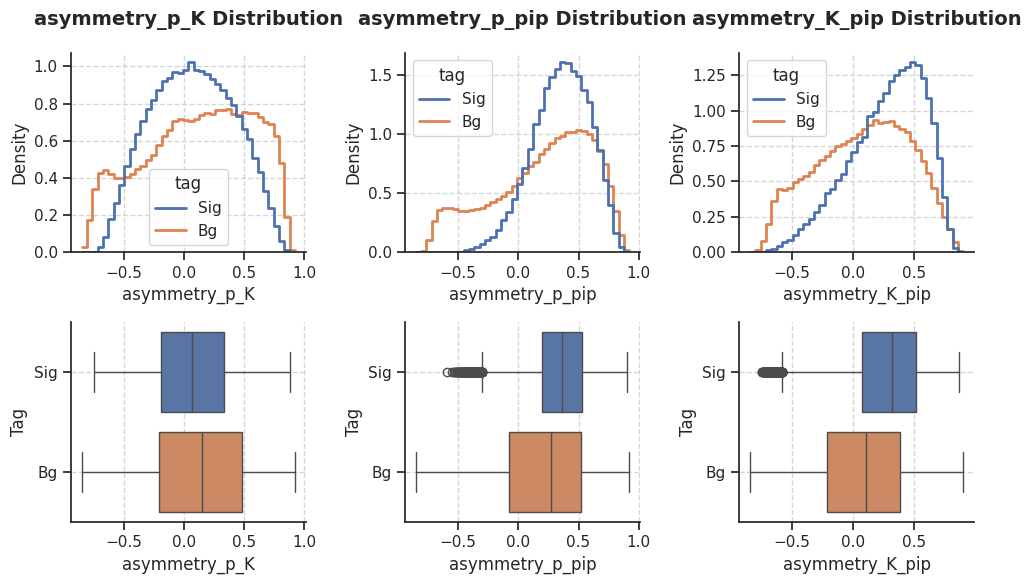

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['asymmetry_p_K', 'asymmetry_p_pip', 'asymmetry_K_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### OA_asymmetry_p_K, OA_asymmetry_p_pip, OA_asymmetry_K_pip

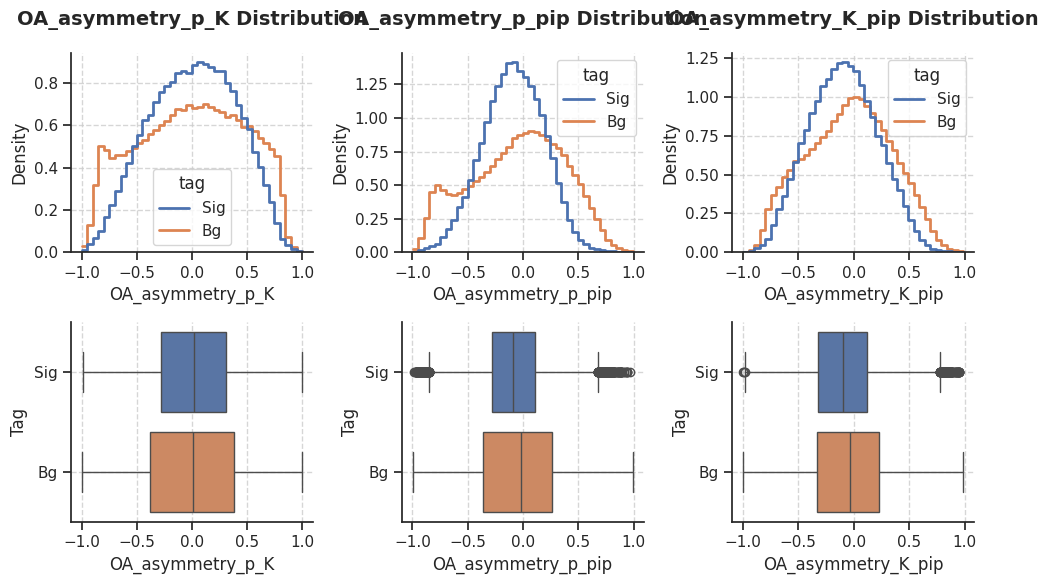

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['OA_asymmetry_p_K', 'OA_asymmetry_p_pip', 'OA_asymmetry_K_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### min_pt_daughter, max_pt_daughter, pt_range

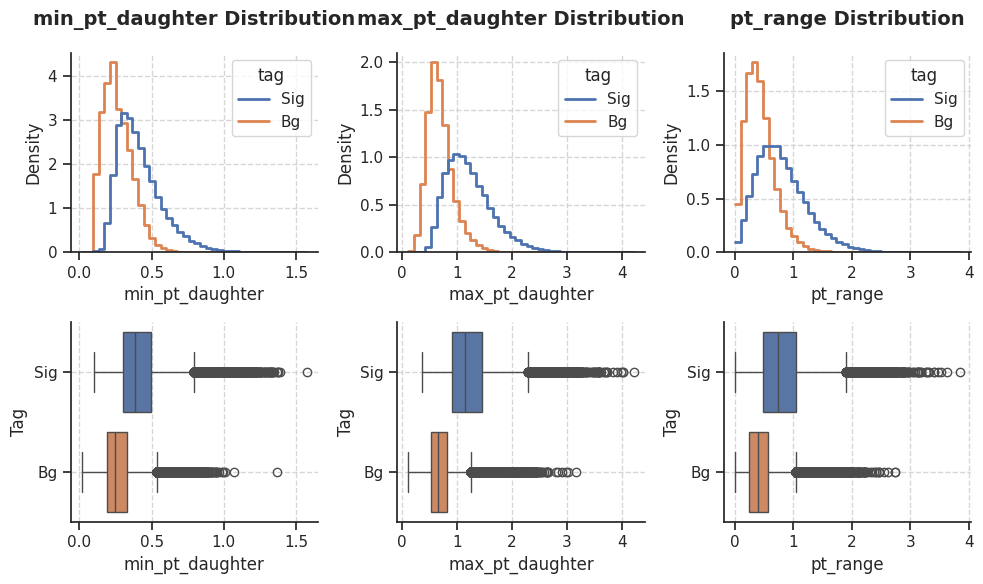

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['min_pt_daughter', 'max_pt_daughter', 'pt_range']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### min_OA_daughter, max_OA_daughter, OA_range

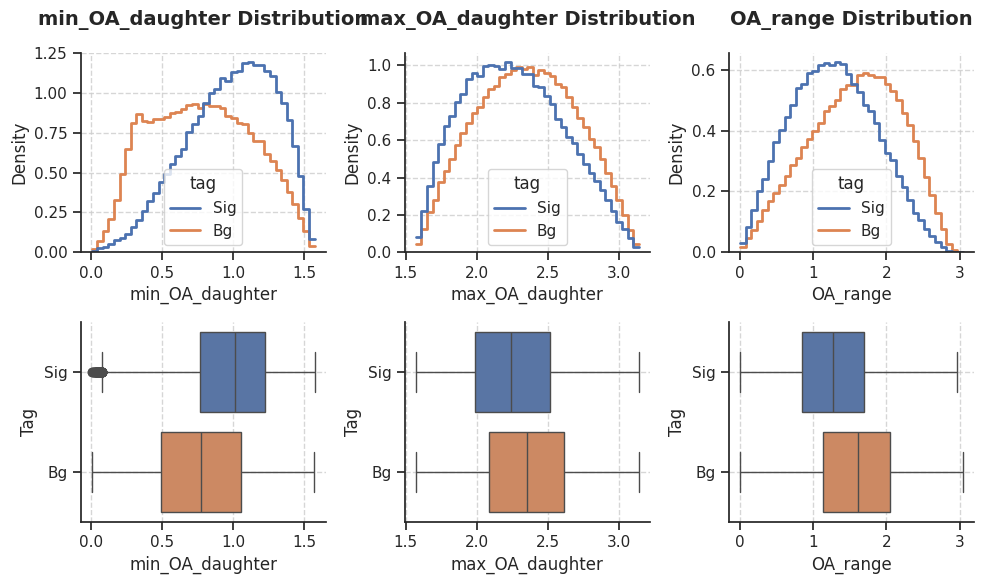

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['min_OA_daughter', 'max_OA_daughter', 'OA_range']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### min_chi2_daughter, max_chi2_daughter, chi2_range

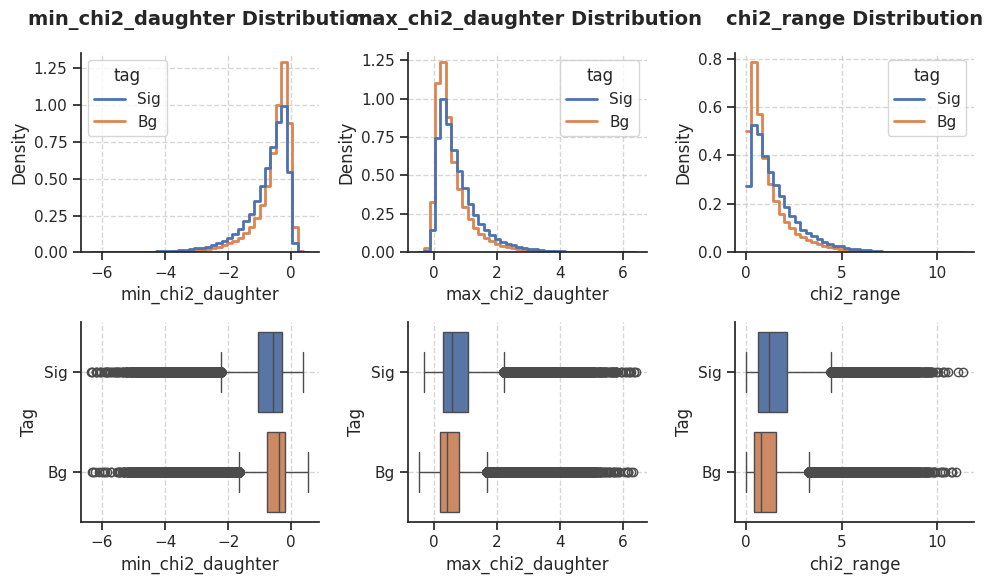

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['min_chi2_daughter', 'max_chi2_daughter', 'chi2_range']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### energy_asymmetry_p_total, pt_cv, OA_cv

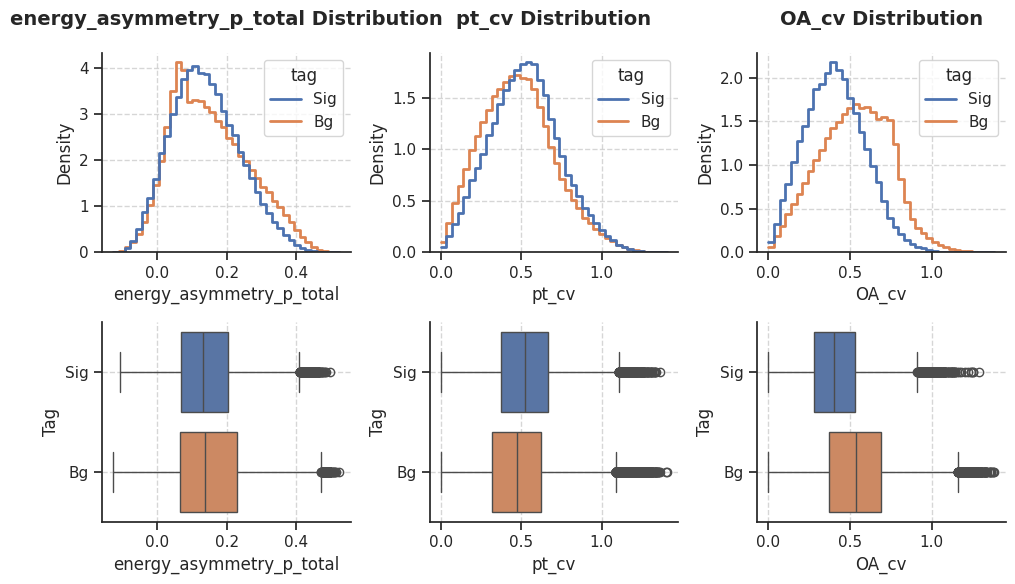

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['energy_asymmetry_p_total', 'pt_cv', 'OA_cv']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### pt_eta_correlation_p, pt_eta_correlation_K, pt_eta_correlation_pip

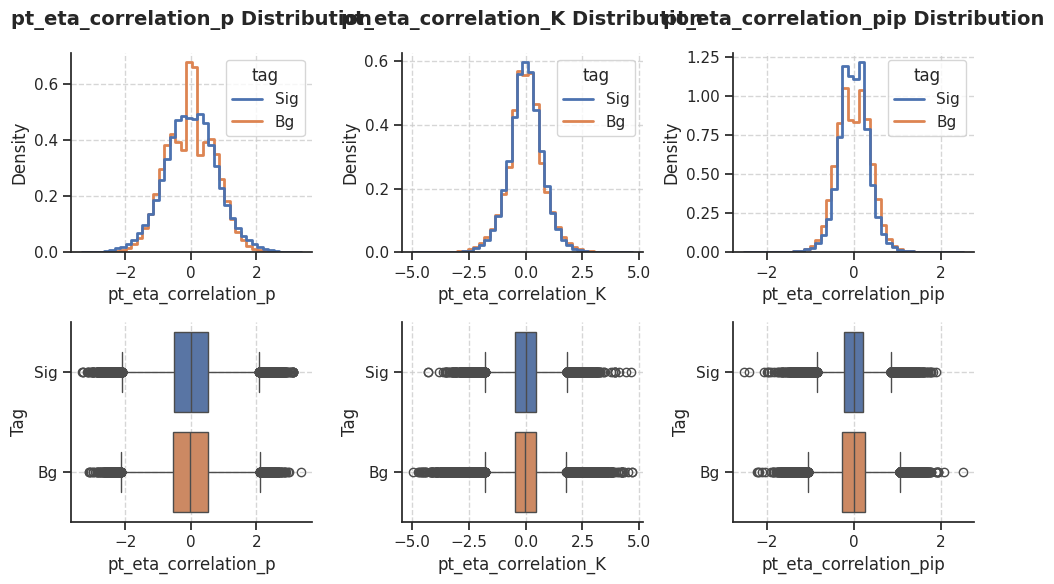

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['pt_eta_correlation_p', 'pt_eta_correlation_K', 'pt_eta_correlation_pip']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### ctau_pt_product, mass_pt_product, xF_pt_product

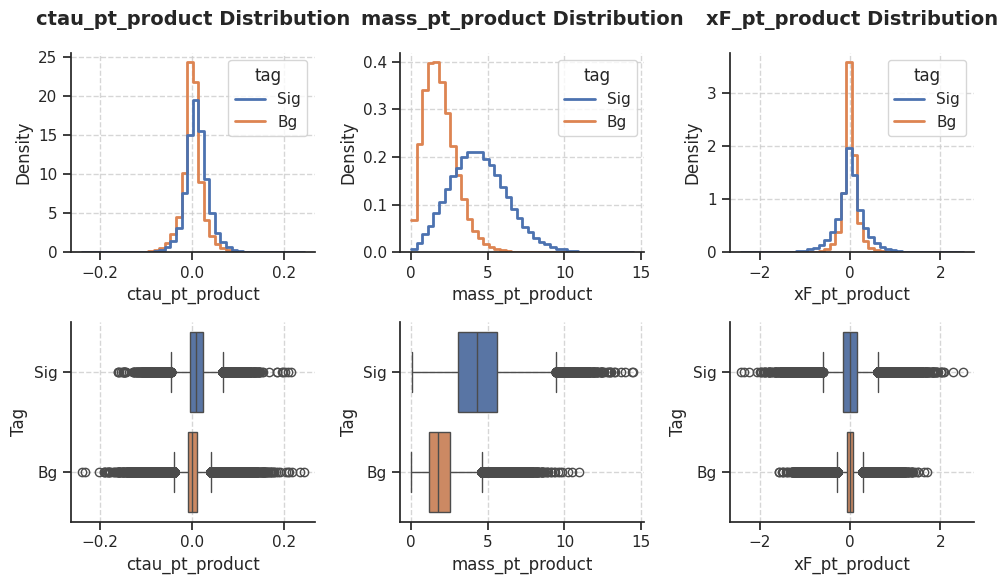

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['ctau_pt_product', 'mass_pt_product', 'xF_pt_product']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### is_high_pt, is_long_lived, is_well_separated

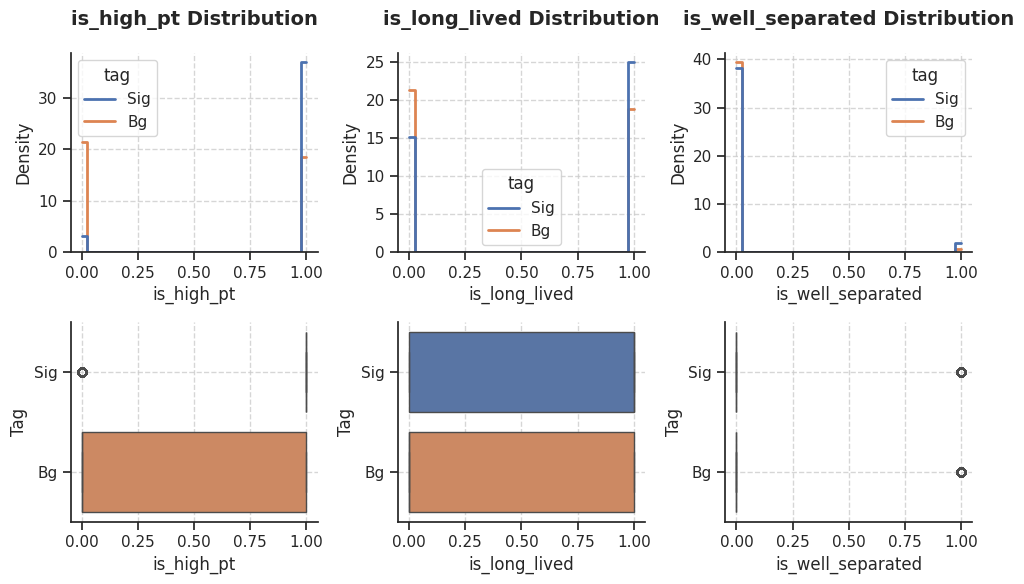

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['is_high_pt', 'is_long_lived', 'is_well_separated']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### is_mass_window, l_over_dl_pt_product,

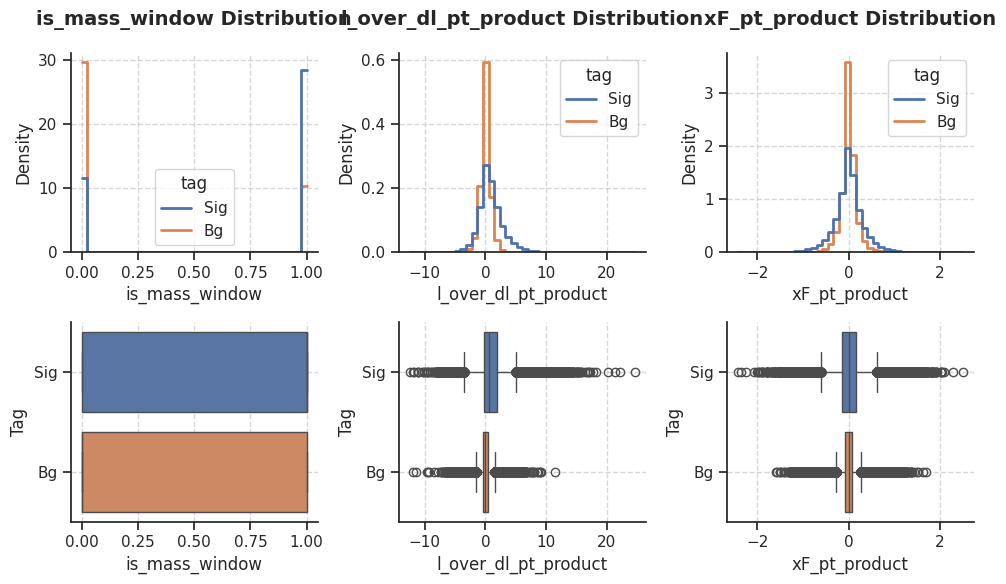

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['is_mass_window', 'l_over_dl_pt_product']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### pt_norm_ratio, p_norm_ratio, chi2_consistency

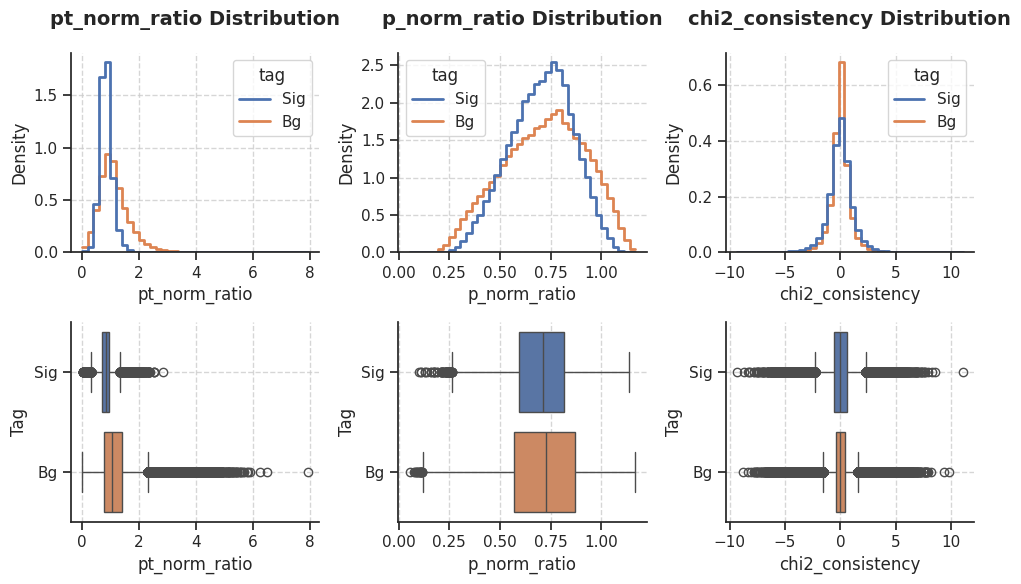

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['pt_norm_ratio', 'p_norm_ratio', 'chi2_consistency']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### sum_squares_chi2_Lc_xy, sum_squares_dca_Lc_xy, sum_squares_dca_custom_Lc_xy

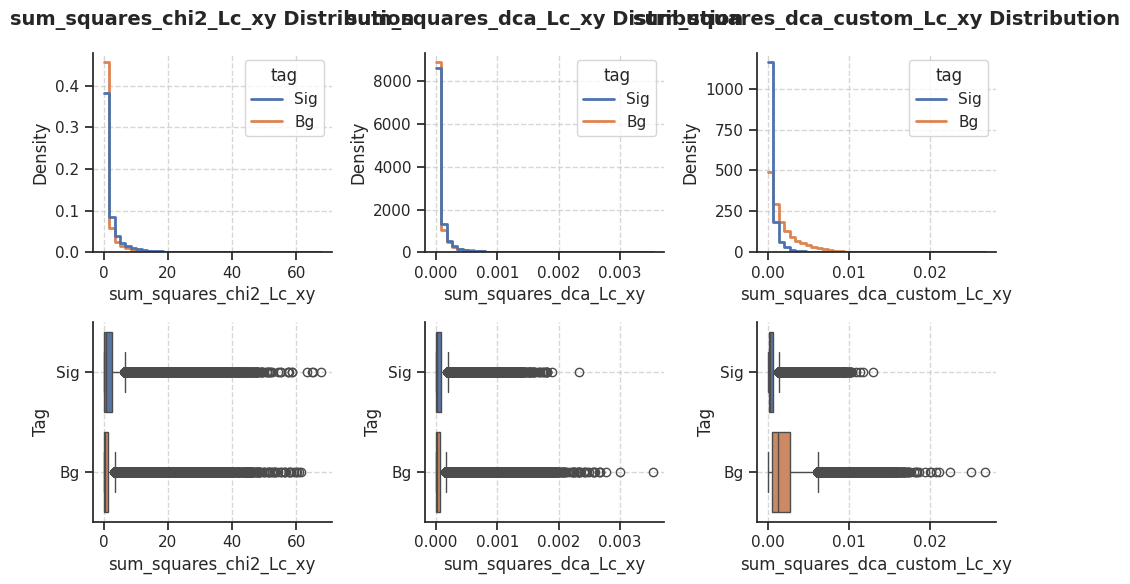

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['sum_squares_chi2_Lc_xy', 'sum_squares_dca_Lc_xy', 'sum_squares_dca_custom_Lc_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### sum_squares_chi2_PV_xy, sum_squares_dca_PV_xy, sum_squares_dca_custom_PV_xy

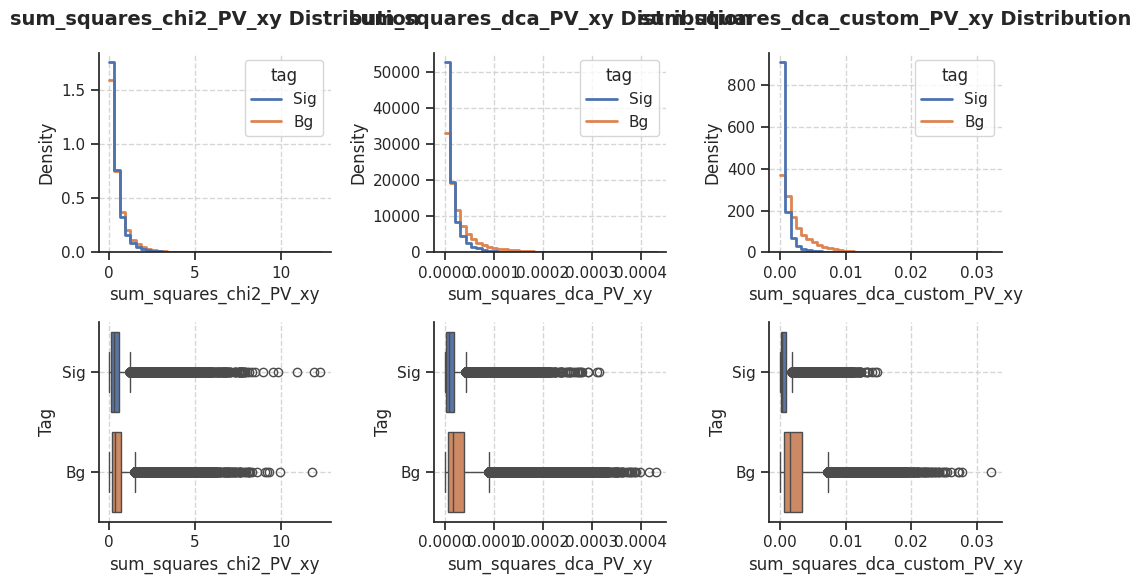

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['sum_squares_chi2_PV_xy', 'sum_squares_dca_PV_xy', 'sum_squares_dca_custom_PV_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_PV_dca_significance, K_PV_dca_significance, pip_PV_dca_significance

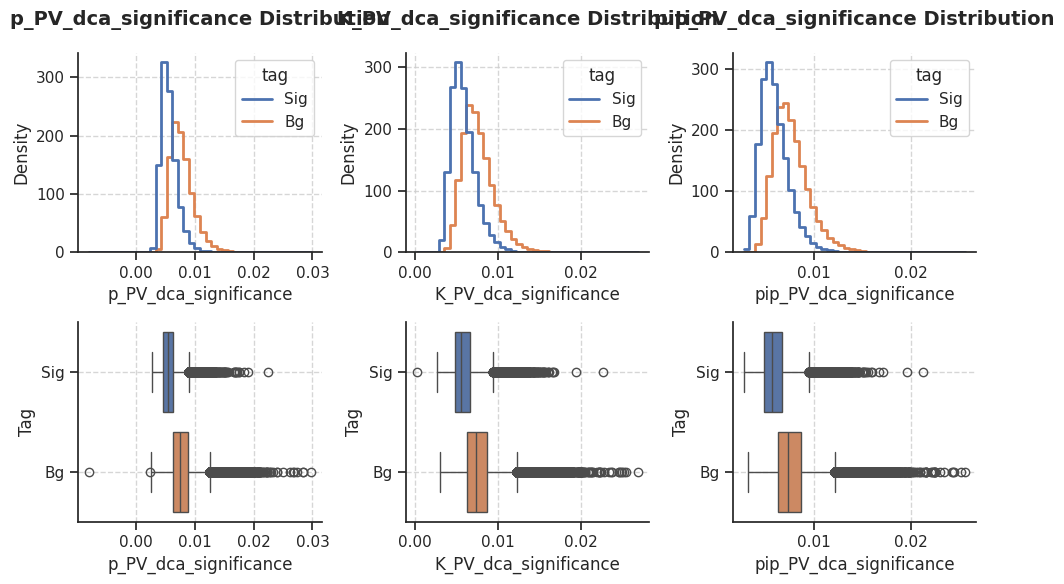

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_PV_dca_significance', 'K_PV_dca_significance', 'pip_PV_dca_significance']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### p_Lc_dca_significance, K_Lc_dca_significance, pip_Lc_dca_significance

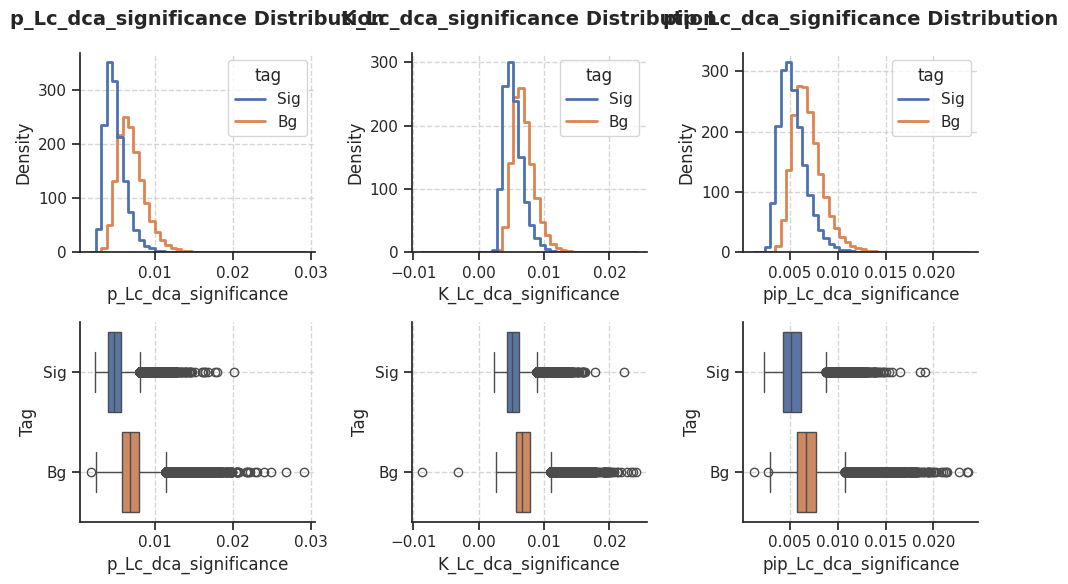

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['p_Lc_dca_significance', 'K_Lc_dca_significance', 'pip_Lc_dca_significance']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### mean_chi2_to_PV, mean_chi2_to_Lc, Lc_dca_significance

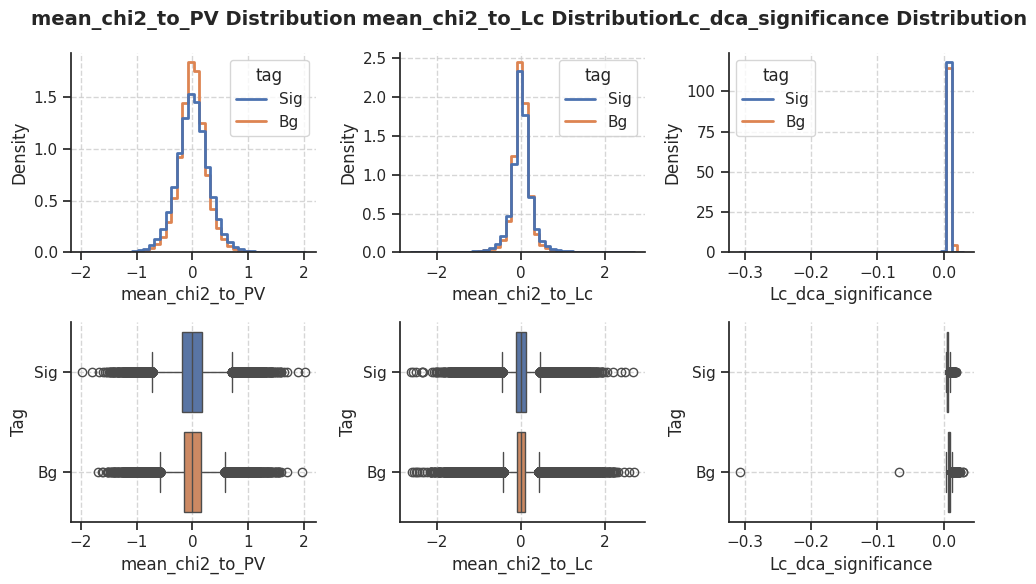

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['mean_chi2_to_PV', 'mean_chi2_to_Lc', 'Lc_dca_significance']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### max_dca_Lc_xy, min_dca_Lc_xy, max_dca_PV_xy

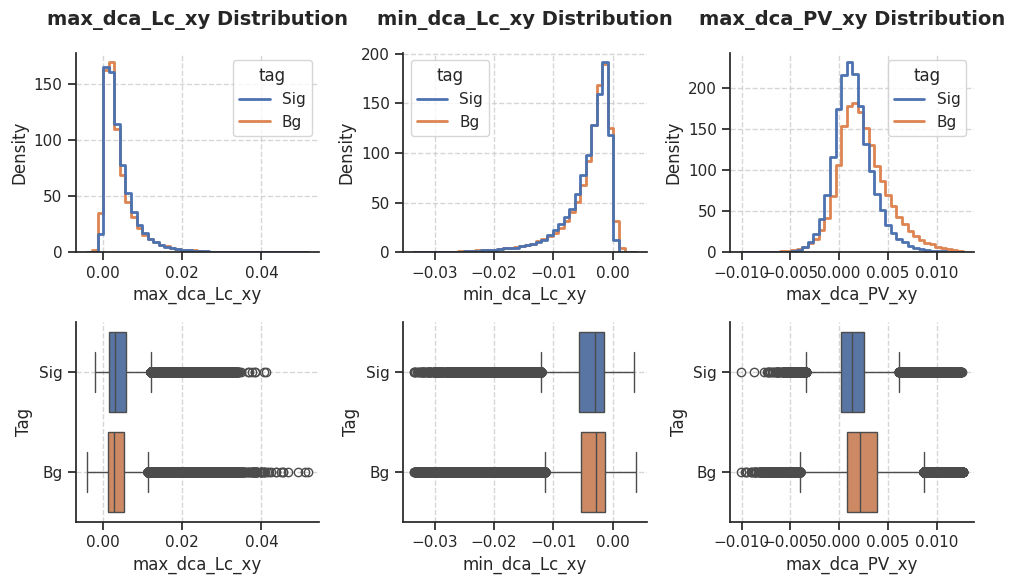

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['max_dca_Lc_xy', 'min_dca_Lc_xy', 'max_dca_PV_xy']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### min_dca_PV_xy, max_dca_Lc_xy_custom, min_dca_Lc_xy_custom

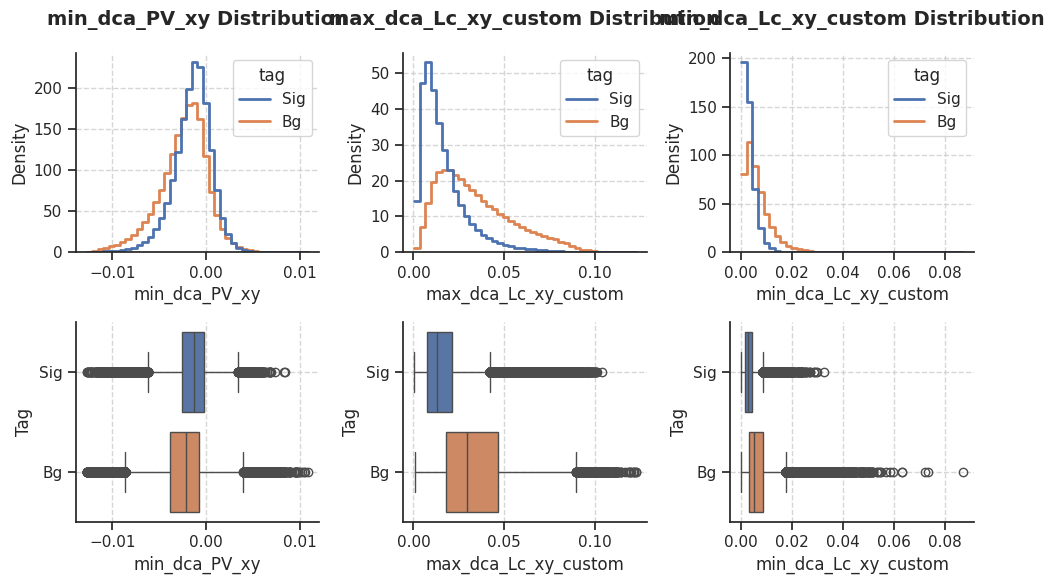

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['min_dca_PV_xy', 'max_dca_Lc_xy_custom', 'min_dca_Lc_xy_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### max_dca_PV_xy_custom, min_dca_PV_xy_custom, dca_sum_consistency

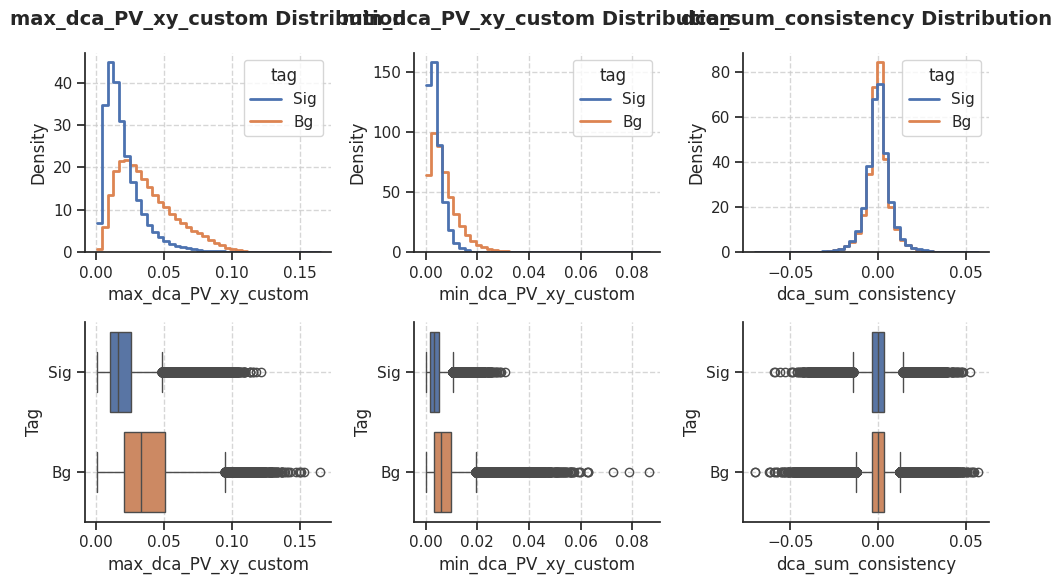

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['max_dca_PV_xy_custom', 'min_dca_PV_xy_custom', 'dca_sum_consistency']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

#### dca_sum_consistency_custom, mean_dca, mean_dca_custom

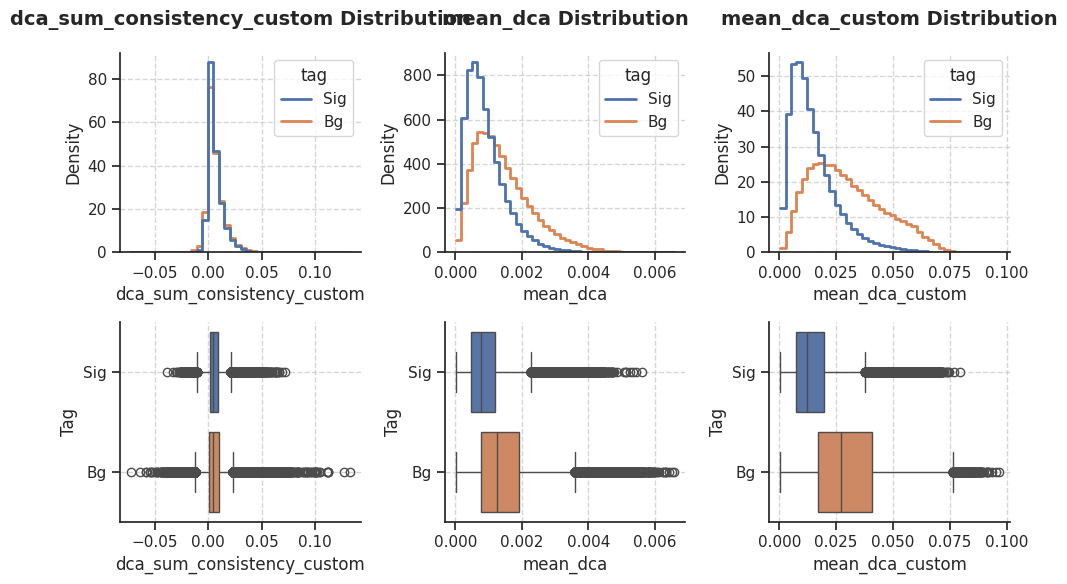

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['dca_sum_consistency_custom', 'mean_dca', 'mean_dca_custom']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=train_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()

# Features 2D Distributions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid")

# df1 = proc_df.loc[proc_df['tag'] == 'Sig', check + ['tag']].iloc[:1000, :]
# df2 = proc_df.loc[proc_df['tag'] == 'Bg', check + ['tag']].iloc[:1000, :]
# df = pd.concat([df1, df2], axis=0)

df = proc_df[phys_columns + ['cosAngle_r_Lc_momentum_Lc_xy', 'cosAngle_r_Lc_sum_momentum_xy'] + ['tag']]

plot = sns.pairplot(
    df,
    hue="tag",
    corner=True,
    palette=['#FF6B6B', '#4ECDC4'],
    hue_order=['Sig', 'Bg'],
    plot_kws={'alpha': 0.05, 's': 40, 'edgecolor': 'none'}
)


plot._legend.remove()


legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', 
           markersize=10, label='Signal', alpha=1.0, markeredgewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4', 
           markersize=10, label='Background', alpha=1.0, markeredgewidth=0)
]


plot.fig.legend(handles=legend_elements, 
                loc='center right',
                bbox_to_anchor=(1.02, 0.5),
                frameon=True,
                title='Event Type')


plt.savefig('../plots/phys_columns.png', bbox_inches='tight')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid")

# df1 = proc_df.loc[proc_df['tag'] == 'Sig', check + ['tag']].iloc[:1000, :]
# df2 = proc_df.loc[proc_df['tag'] == 'Bg', check + ['tag']].iloc[:1000, :]
# df = pd.concat([df1, df2], axis=0)

df = proc_df[topolog_columns + ['tag']]

plot = sns.pairplot(
    df,
    hue="tag",
    corner=True,
    palette=['#FF6B6B', '#4ECDC4'],
    hue_order=['Sig', 'Bg'],
    plot_kws={'alpha': 0.05, 's': 40, 'edgecolor': 'none'}
)


plot._legend.remove()


legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', 
           markersize=10, label='Signal', alpha=1.0, markeredgewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4', 
           markersize=10, label='Background', alpha=1.0, markeredgewidth=0)
]


plot.fig.legend(handles=legend_elements, 
                loc='center right',
                bbox_to_anchor=(1.02, 0.5),
                frameon=True,
                title='Event Type')


plt.savefig('../plots/topolog_columns.png', bbox_inches='tight')

# Features Correlations

len(columns)=45
np.linalg.matrix_rank(corr)=np.int64(45)
np.linalg.det(corr)=np.float64(1.702547497486061e-15)

Highly correlated pairs (|corr| > 0):

OA_p            x p_momentum_ratio: 0.6768.
Pt_K            x sum_abs_pt     : 0.6549.
OA_p            x OA_K           : -0.6541.
sum_abs_pt      x min_pt_daughter: 0.6526.
OA_pip          x delta_eta_pip  : -0.6354.
max_dca_Lc_xy   x min_chi2_daughter: -0.6288.
dist_p_Lc_xy_custom x mean_dca_custom: 0.6244.
E_pip           x rapidity_pip   : 0.6156.
pip_Pt_fraction x K_Pt_fraction  : 0.5909.
dist_Lc_PV_xy   x dist_p_PV_xy   : 0.5814.
OA_K            x K_momentum_ratio: 0.5813.
OA_K            x E_K            : 0.5714.
min_OA_daughter x max_OA_daughter: -0.5617.
chi2_Lc         x mean_dca_custom: 0.5531.
dist_pip_Lc_xy_custom x mean_dca_custom: 0.5523.
dist_Lc_PV_xy   x max_dca_PV_xy  : 0.5504.
dist_Lc_PV_xy   x min_dca_PV_xy  : 0.5493.
p_momentum_ratio x p_Pt_fraction  : 0.5412.
sum_abs_pt      x p_Lc_dca_significance: -0.5363.
pip_mo

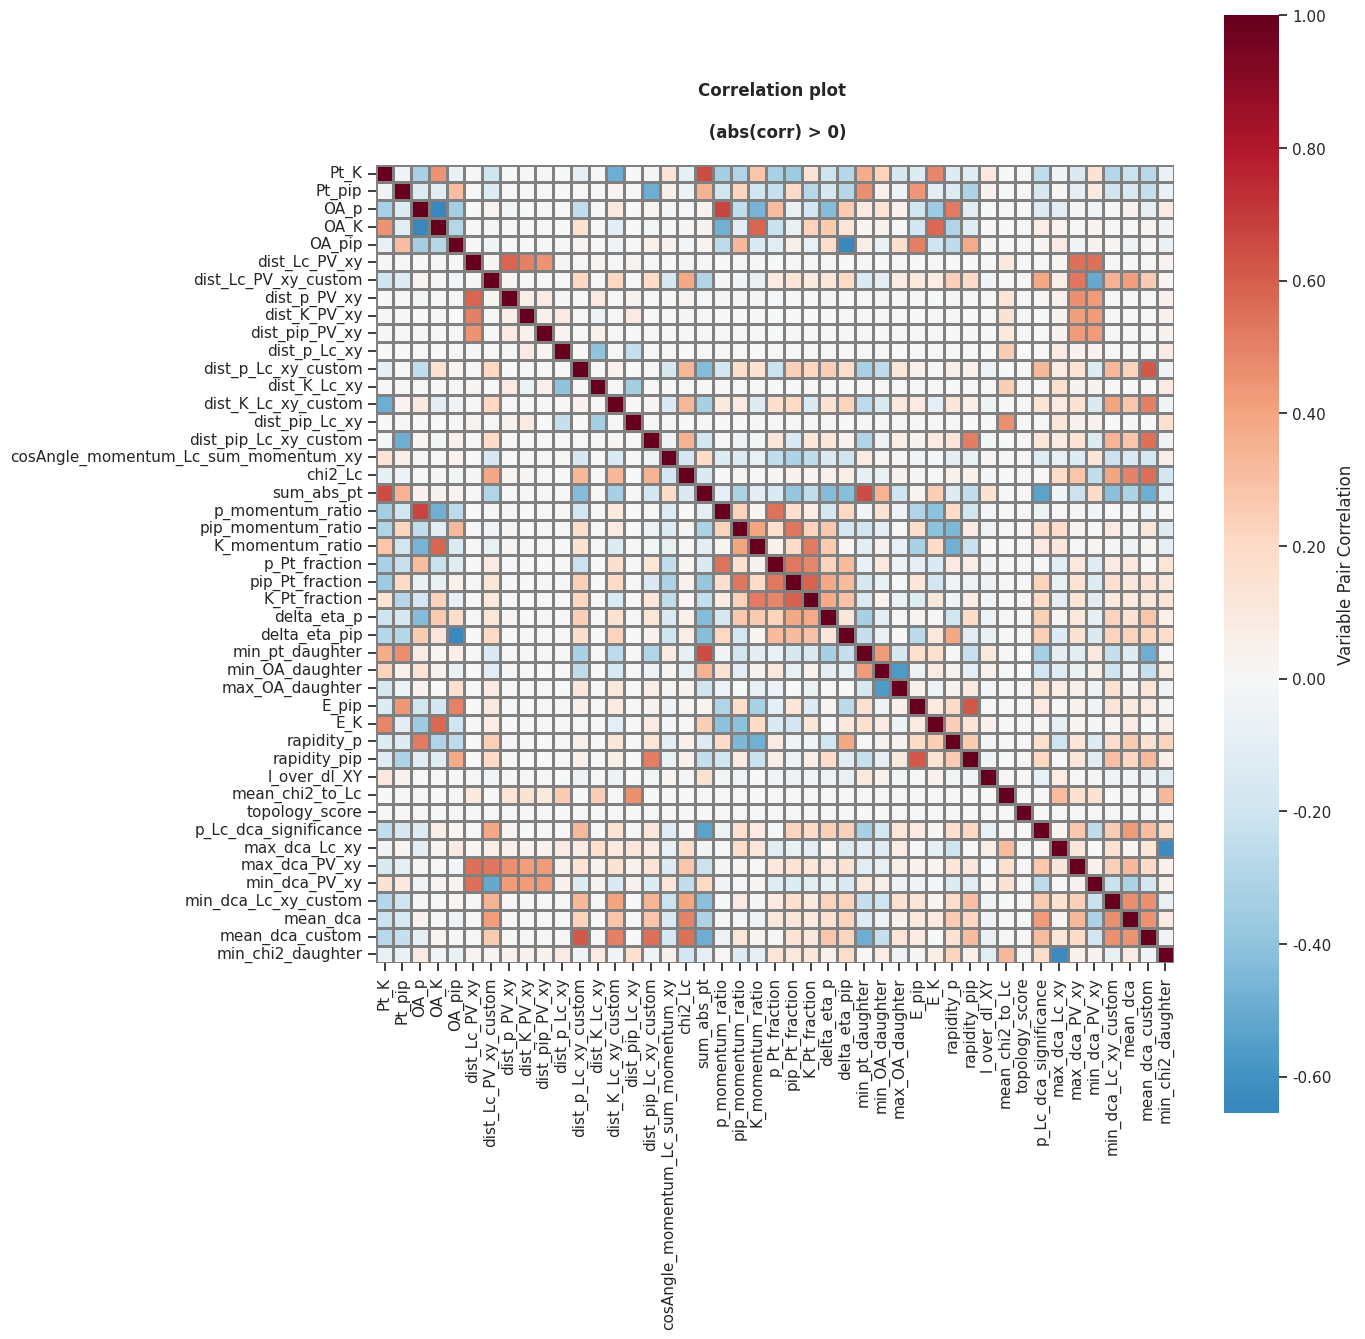

In [3]:
cols = [col for col in CFG.feature_cut_based_sel_low_corr if col in CFG.continual_features]

_ = features_correlation(
    df = train_df,
    columns=cols,
    target=CFG.target_name,
    corr_with_target=False,
    target_values=None,
    min_corr=0,
    figsize=(14, 14)
)

plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/sig_corr.pdf', bbox_inches='tight')

# Features Statistical Importanse

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=50 is greater than n_features=17. All the features will be returned.
  warnings.warn(


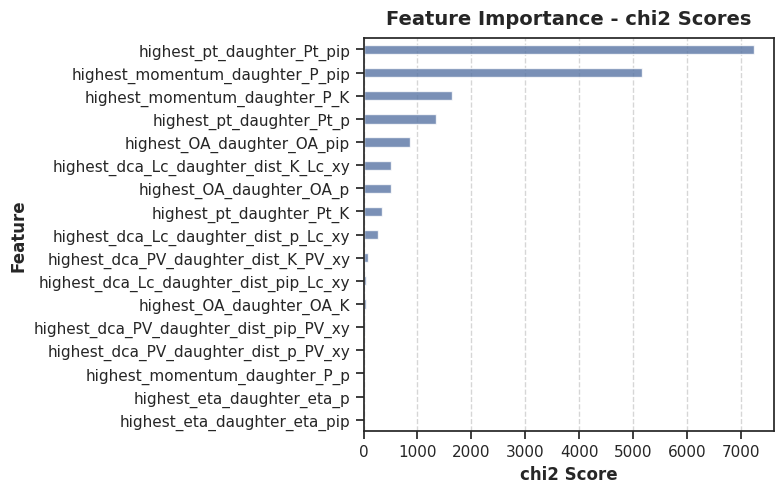

<Figure size 640x480 with 0 Axes>

In [ ]:
cols_to_encode = [
    'highest_pt_daughter', 'highest_momentum_daughter', 'highest_OA_daughter',
    'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
]

temp_df = train_df[cols_to_encode + ['tag']].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, dtype=int), cols_to_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.fit(temp_df)
x_train_encoded = preprocessor.transform(temp_df)

feature_names = preprocessor.get_feature_names_out()

x_train = pd.DataFrame(x_train_encoded, columns=feature_names, index=temp_df.index)


x_df = x_train.drop('tag', axis=1)
y_df = x_train['tag'].map({'Sig': 1, 'Bg': 0})

res_df = feature_stat_importance(x=x_df, y=y_df, method=chi2, select_k_best=50)
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/chi2_FE.pdf')

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=50 is greater than n_features=47. All the features will be returned.
  warnings.warn(


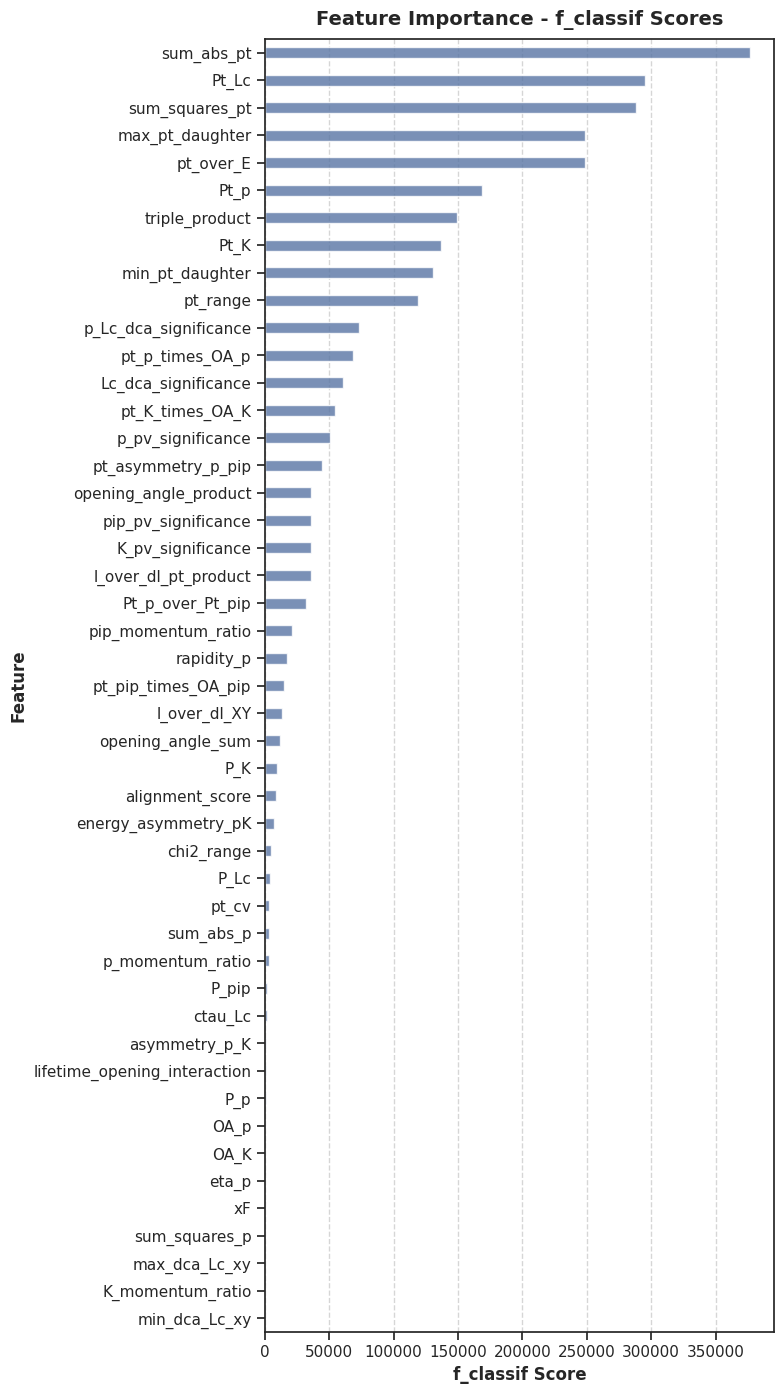

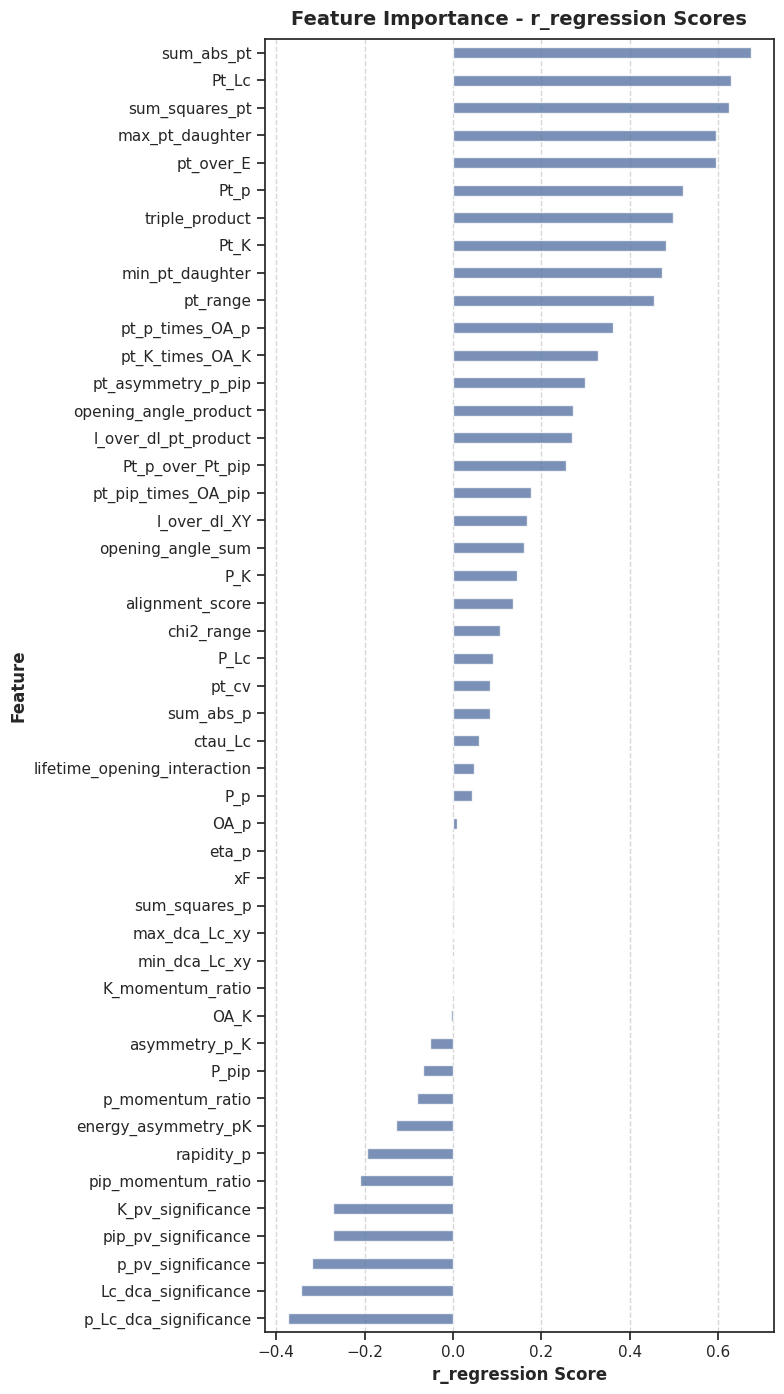

In [4]:
x_df = train_df.drop('tag', axis=1).copy()
y_df = train_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

# x_df = x_df[[col for col in continual_features if col not in bad_features]]
x_df = x_df[[col for col in CFG.feature_set_2 if col in CFG.continual_features]]

res_df = feature_stat_importance(x=x_df, y=y_df, method=f_classif, select_k_best=50)
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/f_classif_FE.pdf', bbox_inches='tight')
res_df = feature_stat_importance(x=x_df, y=y_df, method=r_regression, select_k_best=None)
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/r_regression_FE.pdf', bbox_inches='tight')

In [9]:
for i in res_df.iterrows():
    print(i[1]['feature'], i[1]['score'])

sum_abs_pt 0.6741992048129823
Pt_Lc 0.6283755268941331
sum_squares_pt 0.6243019277662266
max_pt_daughter 0.5959826651486547
pt_over_E 0.5955968595333918
Pt_p 0.5210592376192555
Mt_p 0.5146660437553926
triple_product 0.49834825057105187
Pt_K 0.4819620974154205
Mt_K 0.4815564659825693
min_pt_daughter 0.47319595499495953
pt_range 0.4559607652323382
pt_p_times_OA_p 0.3629710577751272
pt_K_times_OA_K 0.32918125937501214
pt_asymmetry_p_pip 0.29954769147837385
opening_angle_product 0.2725743210820745
l_over_dl_pt_product 0.27022686474582047
Pt_p_over_Pt_pip 0.2562180089487657
pt_asymmetry_K_pip 0.2413201692194627
min_OA_daughter 0.23261539056967404
Pt_K_over_Pt_pip 0.23061029227662688
asymmetry_K_pip 0.2197508490364789
energy_asymmetry_Kpip 0.18890570429541328
pt_pip_times_OA_pip 0.1775167044494979
l_over_dl_XY 0.16863583756918438
Pt_pip 0.1648386236108804
Mt_pip 0.1638499648652766
asymmetry_p_pip 0.163269656616109
sum_abs_OA 0.16128119698681917
opening_angle_sum 0.16128119698681917
ctau_pt_p

# Target proportion

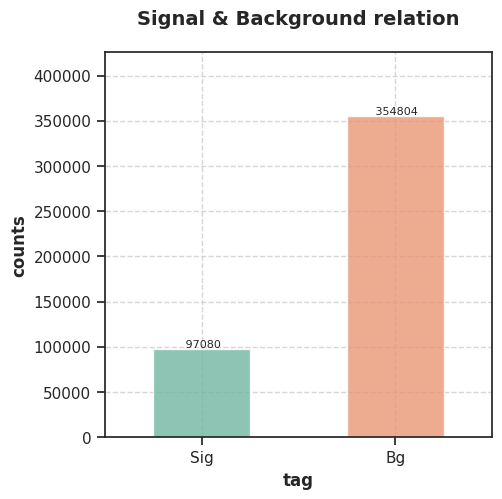

<Figure size 640x480 with 0 Axes>

In [5]:
signal = train_df[train_df['tag'] == 'Sig']
background = train_df[train_df['tag'] == 'Bg']

fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(
    data = pd.DataFrame(train_df['tag']),
    x='tag',
    hue='tag',
    width=0.5,
    alpha=0.8,
    palette='Set2',
    ax=ax
)

max_value = train_df['tag'].value_counts().max()
ax.set_ylim(0, max_value * 1.2)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + height * 0.001,
                f'{height: .0f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Signal & Background relation", fontsize=14, fontweight='bold', pad=20)

ax.set_xlabel("tag", fontweight='bold')
ax.set_ylabel("counts", fontweight='bold')

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

ax.grid(True, alpha=0.8, linestyle='--')

plt.show()
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/sig_bg_relation_total_train.pdf')

# Dalitz Plots

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:76: SyntaxWarning: invalid escape sequence '\p'
<>:83: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:97: SyntaxWarning: invalid escape sequence '\p'
<>:103: SyntaxWarning: invalid escape sequence '\p'
<>:109: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:76: SyntaxWarning: invalid escape sequence '\p'
<>:83: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:97: SyntaxWarning: invalid escape sequence '\p'
<>:103: SyntaxWarning: invalid escape sequence '\p'
<>:109: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_22960/654942277.py:57: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title('Projection: $m^2(p\pi^+)$', fontsize=14)
/tmp/ipykernel_22960/654942277.py:63

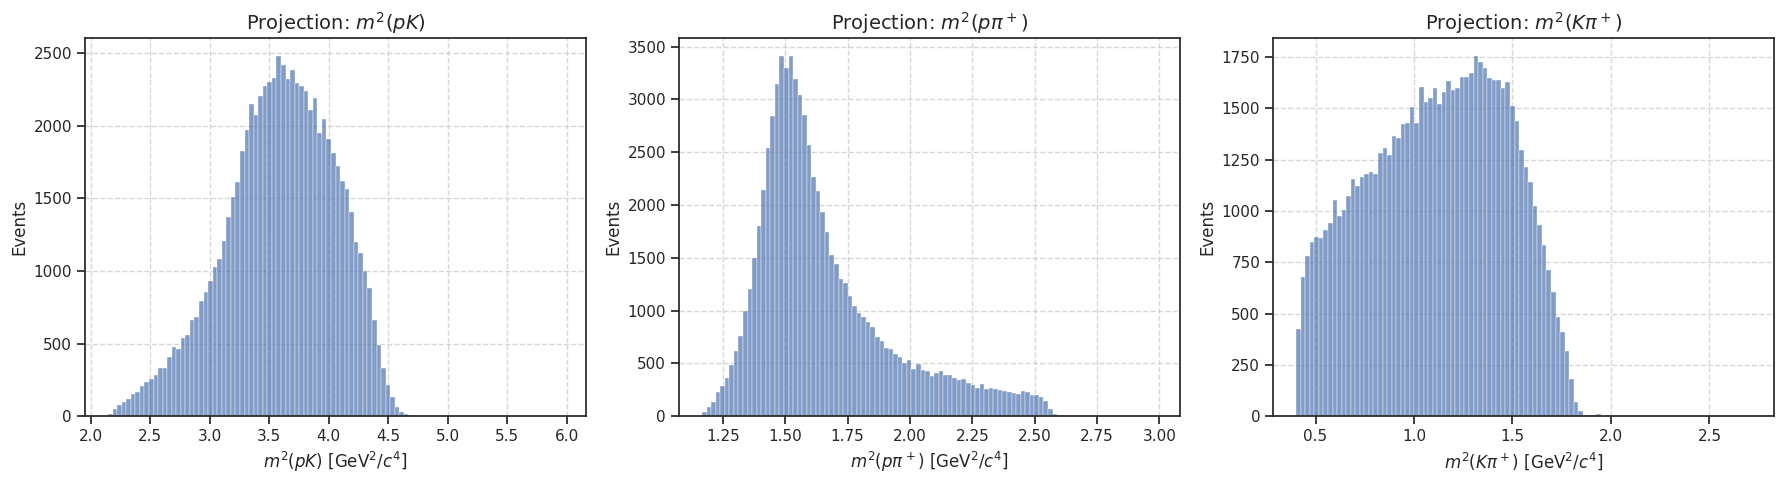

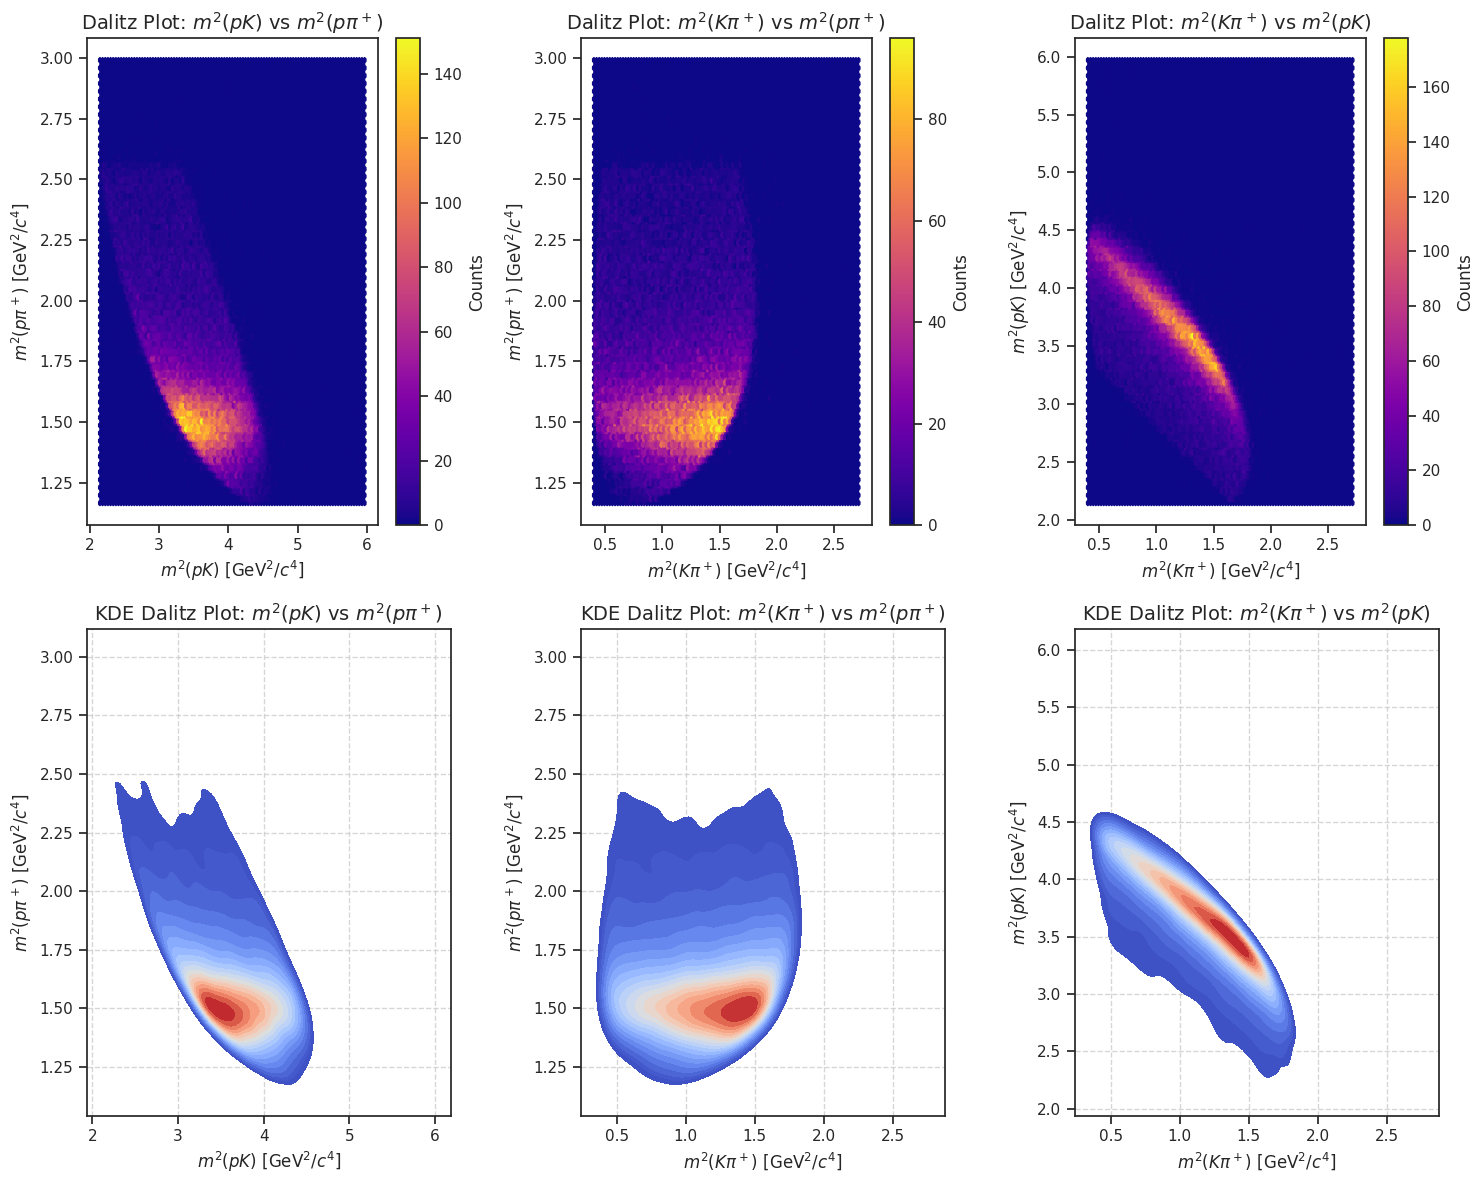


=== Dalitz Plot Statistics ===
Total events: 74553

Invariant mass squared ranges:
m²(pK): [2.146, 5.969] GeV²/c⁴
m²(pπ⁺): [1.167, 2.991] GeV²/c⁴
m²(Kπ⁺): [0.401, 2.712] GeV²/c⁴


In [11]:
df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_dalitz.csv')
df = df[df.true_decay == 1]


def calc_mass_squared(px1, py1, pz1, px2, py2, pz2, m1, m2):
    """
    Calculate invariant mass squared of two particles
    """
    
    E1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)
    E2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)

    Etot = E1 + E2
    pxtot = px1 + px2
    pytot = py1 + py2
    pztot = pz1 + pz2
    
    m2_inv = Etot**2 - (pxtot**2 + pytot**2 + pztot**2)
    
    return m2_inv


df['m2_pK'] = calc_mass_squared(
    df['Px_p'], df['Py_p'], df['Pz_p'],
    df['Px_k'], df['Py_k'], df['Pz_k'],
    CFG.m_proton, CFG.m_kaon
)

df['m2_ppip'] = calc_mass_squared(
    df['Px_p'], df['Py_p'], df['Pz_p'],
    df['Px_pip'], df['Py_pip'], df['Pz_pip'],
    CFG.m_proton, CFG.m_pion
)

df['m2_Kpip'] = calc_mass_squared(
    df['Px_k'], df['Py_k'], df['Pz_k'],
    df['Px_pip'], df['Py_pip'], df['Pz_pip'],
    CFG.m_kaon, CFG.m_pion
)

mask = (df['m2_pK'] < 10) & (df['m2_ppip'] < 3) & (df['m2_Kpip'] < 4)

df = df.loc[mask]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1D projections
sns.histplot(data=df, x='m2_pK', bins=100, alpha=0.7, ax=axes[0])
axes[0].set_xlabel(r'$m^2(pK)$ [GeV$^2/c^4$]', fontsize=12)
axes[0].set_ylabel('Events', fontsize=12)
axes[0].set_title('Projection: $m^2(pK)$', fontsize=14)
axes[0].grid(True, alpha=0.8, linestyle='--')

sns.histplot(data=df, x='m2_ppip', bins=100, alpha=0.7, ax=axes[1])
axes[1].set_xlabel(r'$m^2(p\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[1].set_ylabel('Events', fontsize=12)
axes[1].set_title('Projection: $m^2(p\pi^+)$', fontsize=14)
axes[1].grid(True, alpha=0.8, linestyle='--')

sns.histplot(data=df, x='m2_Kpip', bins=100, alpha=0.7, ax=axes[2])
axes[2].set_xlabel(r'$m^2(K\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[2].set_ylabel('Events', fontsize=12)
axes[2].set_title('Projection: $m^2(K\pi^+)$', fontsize=14)
axes[2].grid(True, alpha=0.8, linestyle='--')

plt.tight_layout()
plt.show()
fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/dalitz_projections.pdf')

fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# 1. (m2_pK vs m2_ppip)
hb = axes[0, 0].hexbin(df['m2_pK'], df['m2_ppip'], gridsize=100, cmap='plasma')
axes[0, 0].set_xlabel(r'$m^2(pK)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 0].set_ylabel(r'$m^2(p\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 0].set_title('Dalitz Plot: $m^2(pK)$ vs $m^2(p\pi^+)$', fontsize=14)
plt.colorbar(hb, ax=axes[0, 0], label='Counts')

# 2. (m2_Kpip vs m2_ppip)
hb2 = axes[0, 1].hexbin(df['m2_Kpip'], df['m2_ppip'], gridsize=100, cmap='plasma')
axes[0, 1].set_xlabel(r'$m^2(K\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 1].set_ylabel(r'$m^2(p\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 1].set_title('Dalitz Plot: $m^2(K\pi^+)$ vs $m^2(p\pi^+)$', fontsize=14)
plt.colorbar(hb2, ax=axes[0, 1], label='Counts')

# 3. (m2_Kpip vs m2_pK)
hb3 = axes[0, 2].hexbin(df['m2_Kpip'], df['m2_pK'], gridsize=100, cmap='plasma')
axes[0, 2].set_xlabel(r'$m^2(K\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 2].set_ylabel(r'$m^2(pK)$ [GeV$^2/c^4$]', fontsize=12)
axes[0, 2].set_title('Dalitz Plot: $m^2(K\pi^+)$ vs $m^2(pK)$', fontsize=14)
plt.colorbar(hb3, ax=axes[0, 2], label='Counts')

# 4. KDE
sns.kdeplot(data=df, x='m2_pK', y='m2_ppip', cmap='coolwarm', fill=True, thresh=0.05, ax=axes[1, 0], levels=20)
axes[1, 0].set_xlabel(r'$m^2(pK)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 0].set_ylabel(r'$m^2(p\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 0].set_title('KDE Dalitz Plot: $m^2(pK)$ vs $m^2(p\pi^+)$', fontsize=14)
axes[1, 0].grid(True, alpha=0.8, linestyle='--')

sns.kdeplot(data=df, x='m2_Kpip', y='m2_ppip', cmap='coolwarm', fill=True, thresh=0.05, ax=axes[1, 1], levels=20)
axes[1, 1].set_xlabel(r'$m^2(K\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 1].set_ylabel(r'$m^2(p\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 1].set_title('KDE Dalitz Plot: $m^2(K\pi^+)$ vs $m^2(p\pi^+)$', fontsize=14)
axes[1, 1].grid(True, alpha=0.8, linestyle='--')

sns.kdeplot(data=df, x='m2_Kpip', y='m2_pK', cmap='coolwarm', fill=True, thresh=0.05, ax=axes[1, 2], levels=20)
axes[1, 2].set_xlabel(r'$m^2(K\pi^+)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 2].set_ylabel(r'$m^2(pK)$ [GeV$^2/c^4$]', fontsize=12)
axes[1, 2].set_title('KDE Dalitz Plot: $m^2(K\pi^+)$ vs $m^2(pK)$', fontsize=14)
axes[1, 2].grid(True, alpha=0.8, linestyle='--')

plt.tight_layout()
plt.show()
fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/dalitz.pdf')

# Print basic statistics
print("\n=== Dalitz Plot Statistics ===")
print(f"Total events: {len(df)}")
print(f"\nInvariant mass squared ranges:")
print(f"m²(pK): [{df['m2_pK'].min():.3f}, {df['m2_pK'].max():.3f}] GeV²/c⁴")
print(f"m²(pπ⁺): [{df['m2_ppip'].min():.3f}, {df['m2_ppip'].max():.3f}] GeV²/c⁴")
print(f"m²(Kπ⁺): [{df['m2_Kpip'].min():.3f}, {df['m2_Kpip'].max():.3f}] GeV²/c⁴")
